# Decode L/R Alternations at Critical Choice Points

Aggregates across all sessions and blocks matching a restriction.

For each critical CP visit, computes:
- **time_lr_s** — total time the decode was in L or R
- **prop_chosen** — proportion of L+R time representing the rat's chosen direction
- **n_lr_sweeps** — number of separate L/R sweeps (`none` gaps break runs, so R-none-R = 2 sweeps)
- **frac_sweeps_chosen** — fraction of those sweeps that represent the chosen direction

Results are stored in `stats_df` (critical CPs only) and `all_stats_df` (every junction).
Both include `nwb_file_name`, `epoch`, and `block` columns for filtering and faceting.

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hexmaze import (
    get_critical_choice_points,
    get_hex_centroids,
)

import spyglass.common as sgc
from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock, HexCentroids, HexMazeChoice
from spyglass_hexmaze.hex_maze_decoding import HexMazeJunctionDecode

In [5]:
HexMazeJunctionDecode.populate()

[2026-05-25 20:20:19,124][WARNING]: Skipped checksum for file with hash: 8b2f0594-9fa0-addf-b7f2-3f2b360d2d20, and path: /stelmo/nwb/analysis/IM-1594_20230725/IM-1594_20230725_6HESWXRT4P.nwb
[2026-05-25 20:20:19,135][WARNING]: Skipped checksum for file with hash: 8b2f0594-9fa0-addf-b7f2-3f2b360d2d20, and path: /stelmo/nwb/analysis/IM-1594_20230725/IM-1594_20230725_6HESWXRT4P.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

{'success_count': 6, 'error_list': []}

In [51]:
# Set restriction: will aggregate all matching sessions and blocks
restriction = ""#nwb_file_name LIKE 'IM-19%'"
decode_keys = (HexMazeJunctionDecode()).fetch("KEY", order_by="nwb_file_name, epoch")
print(f"Found {len(decode_keys)} epoch(s) matching restriction")

Found 24 epoch(s) matching restriction


In [52]:
# ---- Collect stats across all sessions and blocks ----
# stats_df  — critical CPs only
# all_stats_df — every junction (for critical vs other comparison)

NONLOCAL_DIST_CM = 10  # minimum decode distance to count a timepoint or sweep as "nonlocal"
EXCLUDED_JUNCTIONS = {4, 48, 49}  # arm-entry hexes, not true choice points

def _compute_junction_stats(group, rat_dir, junc, entry_hex, critical_cps,
                             nwb_file_name, epoch, block, trial_num):
    """Return one stats dict for a single junction visit group."""
    # median sample interval (seconds)
    dt = group.index.to_series().diff().median()
    # decode direction at each timepoint
    decode_dir  = group["decode_junction_direction"]
    # distance of decode from rat (cm)
    decode_dist = group["decode_distance"]

    # Timepoint-level masks
    cov_mask = group["spatial_cov"] < 500  # confident decode
    lr_mask = decode_dir.isin(["left", "right"]) & cov_mask  # confident decode + decode is L or R
    nonlocal_lr_mask = lr_mask & (decode_dist.abs() > NONLOCAL_DIST_CM)  # confident decode + decode is L or R + nonlocal

    lr_only = decode_dir[lr_mask]
    nonlocal_lr_only = decode_dir[nonlocal_lr_mask]

    # Sweep-level counts: consecutive runs of the same direction;
    # "none"/ambiguous breaks sweeps, spatial_cov is NOT used to break sweeps here
    sweep_ids = (decode_dir != decode_dir.shift()).cumsum()
    lr_runs         = []  # direction of each L/R sweep (one entry per sweep)
    remote_runs     = []  # same but only sweeps that went nonlocal at least once
    sweep_durations = [] # duration (s) of each L/R sweep
    sweep_max_dists = [] # max decode distance from rat (cm) within each L/R sweep

    for _, sweep in group.groupby(sweep_ids, sort=False):
        d = sweep["decode_junction_direction"].iloc[0]
        if d not in ("left", "right"):
            continue  # ambiguous/none sweep, skip
        lr_runs.append(d)
        sweep_durations.append(len(sweep) * dt)
        sweep_max_dists.append(sweep["decode_distance"].abs().max())
        if (sweep["decode_distance"].abs() > NONLOCAL_DIST_CM).any():
            remote_runs.append(d)  # at least one timepoint was nonlocal

    lr_runs         = pd.Series(lr_runs)
    remote_runs     = pd.Series(remote_runs)
    sweep_durations = pd.Series(sweep_durations)
    sweep_max_dists = pd.Series(sweep_max_dists)

    return {
        "nwb_file_name": nwb_file_name,
        "epoch":         epoch,
        "block":         block,
        "trial":         trial_num,
        "junction":      junc,
        "entry_hex":     entry_hex,
        "rat_direction": rat_dir,
        "is_critical":   junc in critical_cps,
        # Time metrics
        "time_lr_s":        len(lr_only) * dt,
        "nonlocal_time_lr_s": len(nonlocal_lr_only) * dt,
        # Proportion of (nonlocal) L+R time representing chosen direction
        "prop_chosen":          (lr_only == rat_dir).mean()         if len(lr_only) > 0         else np.nan,
        "prop_nonlocal_chosen": (nonlocal_lr_only == rat_dir).mean() if len(nonlocal_lr_only) > 0 else np.nan,
        # Sweep counts
        "n_lr_sweeps":     len(lr_runs),
        "n_nonlocal_sweeps": len(remote_runs),
        # Fraction of (nonlocal) sweeps representing chosen direction
        "frac_sweeps_chosen":          (lr_runs == rat_dir).mean()     if len(lr_runs) > 0     else np.nan,
        "frac_nonlocal_sweeps_chosen": (remote_runs == rat_dir).mean() if len(remote_runs) > 0 else np.nan,
        # Sweep duration stats
        "mean_sweep_dur_s":   sweep_durations.mean()   if len(sweep_durations) > 0 else np.nan,
        "median_sweep_dur_s": sweep_durations.median() if len(sweep_durations) > 0 else np.nan,
        "max_sweep_dur_s":    sweep_durations.max()    if len(sweep_durations) > 0 else np.nan,
        # Sweep distance stats
        "mean_sweep_max_dist": sweep_max_dists.mean() if len(sweep_max_dists) > 0 else np.nan,
        "max_sweep_max_dist":  sweep_max_dists.max()  if len(sweep_max_dists) > 0 else np.nan,
    }
    
    
def _collect_sweeps(group, rat_dir, junc, entry_hex, critical_cps,
                    nwb_file_name, epoch, block, trial_num):
    """Return a list of dicts, one per L/R sweep within this junction visit."""
    dt         = group.index.to_series().diff().median()  # median sample interval (s)
    decode_dir = group["decode_junction_direction"]

    # Each contiguous run of the same decode direction is one sweep
    sweep_ids = (decode_dir != decode_dir.shift()).cumsum()

    rows = []
    for _, sweep in group.groupby(sweep_ids, sort=False):
        d = sweep["decode_junction_direction"].iloc[0]
        if d not in ("left", "right"):
            continue  # skip ambiguous/none sweeps

        rows.append({
            # Visit-level metadata (same for all sweeps in this visit)
            "nwb_file_name": nwb_file_name,
            "epoch":         epoch,
            "block":         block,
            "trial":         trial_num,
            "junction":      junc,
            "entry_hex":     entry_hex,
            "rat_direction": rat_dir,
            "is_critical":   junc in critical_cps,
            # Sweep-level info
            "sweep_direction": d,
            "sweep_chosen":    d == rat_dir,                              # does this sweep point where the rat went?
            "sweep_dur_s":     len(sweep) * dt,                           # how long was this sweep
            "sweep_max_dist":  sweep["decode_distance"].abs().max(),      # how far did the decode get from the rat
            "is_nonlocal":     (sweep["decode_distance"].abs() > NONLOCAL_DIST_CM).any(),  # did it ever go nonlocal
        })
    return rows



all_rows = []
all_sweeps = []

for key in decode_keys:
    pos_df = (HexMazeJunctionDecode() & key).fetch1_dataframe()

    for block_row in (HexMazeBlock() & key).fetch(as_dict=True, order_by="block"):
        block_key = {k: block_row[k] for k in ["nwb_file_name", "epoch", "block"]}
        maze = block_row["config_id"]
        critical_cps = get_critical_choice_points(maze)

        for trial_info in (HexMazeBlock.Trial() & block_key).fetch(as_dict=True, order_by="epoch_trial_num"):
            trial_num = trial_info["epoch_trial_num"]
            start, end = (sgc.IntervalList() & {
                "nwb_file_name": trial_info["nwb_file_name"],
                "interval_list_name": trial_info["interval_list_name"]
            }).fetch1("valid_times")[0]
            df_trial = pos_df.loc[start:end]

            junc_entry_series = pd.Series(
                list(zip(df_trial["nearest_junction"], df_trial["junction_entry_hex"])),
                index=df_trial.index
            )
            run_ids = (junc_entry_series != junc_entry_series.shift()).cumsum()

            for _, group in df_trial.groupby(run_ids, sort=False):
                junc = group["nearest_junction"].iloc[0]
                # exclude junctions right next to reward ports
                if junc == -100 or junc in EXCLUDED_JUNCTIONS:
                    continue
                rat_dir = group["rat_junction_direction"].iloc[0]
                # rat turned around instead of going left or right
                if rat_dir not in ("left", "right"):
                    continue
                # junction visit too long (>10s)
                if group.index[-1] - group.index[0] > 10:
                    continue

                shared_kwargs = dict(
                    group=group, rat_dir=rat_dir, junc=junc,
                    entry_hex=group["junction_entry_hex"].iloc[0],
                    critical_cps=critical_cps,
                    nwb_file_name=key["nwb_file_name"],
                    epoch=key["epoch"],
                    block=block_row["block"],
                    trial_num=trial_num,
                )
                all_rows.append(_compute_junction_stats(**shared_kwargs))
                all_sweeps.extend(_collect_sweeps(**shared_kwargs))

    print(f"  {key['nwb_file_name']}  epoch={key['epoch']}  — done")

all_stats_df = pd.DataFrame(all_rows)
stats_df = all_stats_df[all_stats_df["is_critical"]].reset_index(drop=True)
sweeps_df = pd.DataFrame(all_sweeps)

print(f"\nTotal junction visits: {len(all_stats_df)}")
print(f"Critical CP visits:    {len(stats_df)}")
display(stats_df.head(10))

[2026-05-25 21:48:27,492][WARNING]: Skipped checksum for file with hash: cb7f056a-97c5-3807-b487-b6de41c0fffa, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_7D3GBJYFTY.nwb
[2026-05-25 21:48:27,501][WARNING]: Skipped checksum for file with hash: cb7f056a-97c5-3807-b487-b6de41c0fffa, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_7D3GBJYFTY.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

  IM-1478_20220719_.nwb  epoch=0  — done


[2026-05-25 21:49:21,925][WARNING]: Skipped checksum for file with hash: c6e3a284-276e-e54f-50bd-e7b1402a1261, and path: /stelmo/nwb/analysis/IM-1478_20220720/IM-1478_20220720_DKQARP0PO2.nwb
[2026-05-25 21:49:21,932][WARNING]: Skipped checksum for file with hash: c6e3a284-276e-e54f-50bd-e7b1402a1261, and path: /stelmo/nwb/analysis/IM-1478_20220720/IM-1478_20220720_DKQARP0PO2.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

  IM-1478_20220720_.nwb  epoch=0  — done


[2026-05-25 21:50:17,369][WARNING]: Skipped checksum for file with hash: 99155923-ce66-5b92-9909-59f40264ef74, and path: /stelmo/nwb/analysis/IM-1478_20220724/IM-1478_20220724_U14RVRHESJ.nwb
[2026-05-25 21:50:17,377][WARNING]: Skipped checksum for file with hash: 99155923-ce66-5b92-9909-59f40264ef74, and path: /stelmo/nwb/analysis/IM-1478_20220724/IM-1478_20220724_U14RVRHESJ.nwb
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extens

...

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

  Toby20250327_.nwb  epoch=5  — done


/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

  Toby20250327_.nwb  epoch=7  — done

Total junction visits: 21971
Critical CP visits:    6086


,nwb_file_name,epoch,block,trial,junction,entry_hex,rat_direction,is_critical,time_lr_s,nonlocal_time_lr_s,...,prop_nonlocal_chosen,n_lr_sweeps,n_nonlocal_sweeps,frac_sweeps_chosen,frac_nonlocal_sweeps_chosen,mean_sweep_dur_s,median_sweep_dur_s,max_sweep_dur_s,mean_sweep_max_dist,max_sweep_max_dist
0,IM-1478_20220719_.nwb,0,1,2,25,20,right,True,0.082000,0.068000,...,1.000000,2,2,1.000000,1.000000,0.093000,0.093,0.182,17.669383,21.479745
1,IM-1478_20220719_.nwb,0,1,2,21,25,left,True,0.670000,0.580000,...,0.000000,4,3,0.250000,0.000000,0.167500,0.029,0.610,24.184488,37.134797
2,IM-1478_20220719_.nwb,0,1,2,31,26,right,True,0.648000,0.350000,...,0.571429,4,4,0.750000,0.750000,0.162000,0.178,0.244,15.791170,23.036784
3,IM-1478_20220719_.nwb,0,1,3,31,37,right,True,1.450000,1.440000,...,0.719444,6,6,0.333333,0.333333,0.302000,0.193,0.662,44.230020,63.396877
4,IM-1478_20220719_.nwb,0,1,3,25,30,right,True,1.756000,1.582000,...,0.061947,10,5,0.600000,0.200000,0.201600,0.032,1.684,20.773813,82.253296
5,IM-1478_20220719_.nwb,0,1,4,25,20,right,True,0.000000,0.000000,...,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,IM-1478_20220719_.nwb,0,1,4,25,21,right,True,0.728000,0.728000,...,0.000000,1,1,0.000000,0.000000,0.728000,0.728,0.728,44.249189,44.249189
7,IM-1478_20220719_.nwb,0,1,4,25,30,left,True,5.371999,5.357999,...,0.651362,44,44,0.454545,0.454545,0.165727,0.030,2.782,57.646125,89.483857
8,IM-1478_20220719_.nwb,0,1,4,21,25,left,True,0.726000,0.608000,...,0.569079,3,3,0.333333,0.333333,0.248667,0.254,0.450,26.326736,35.209797
9,IM-1478_20220719_.nwb,0,1,4,21,26,left,True,0.168000,0.046000,...,0.956522,2,2,0.500000,0.500000,0.084000,0.084,0.166,12.647113,13.520282


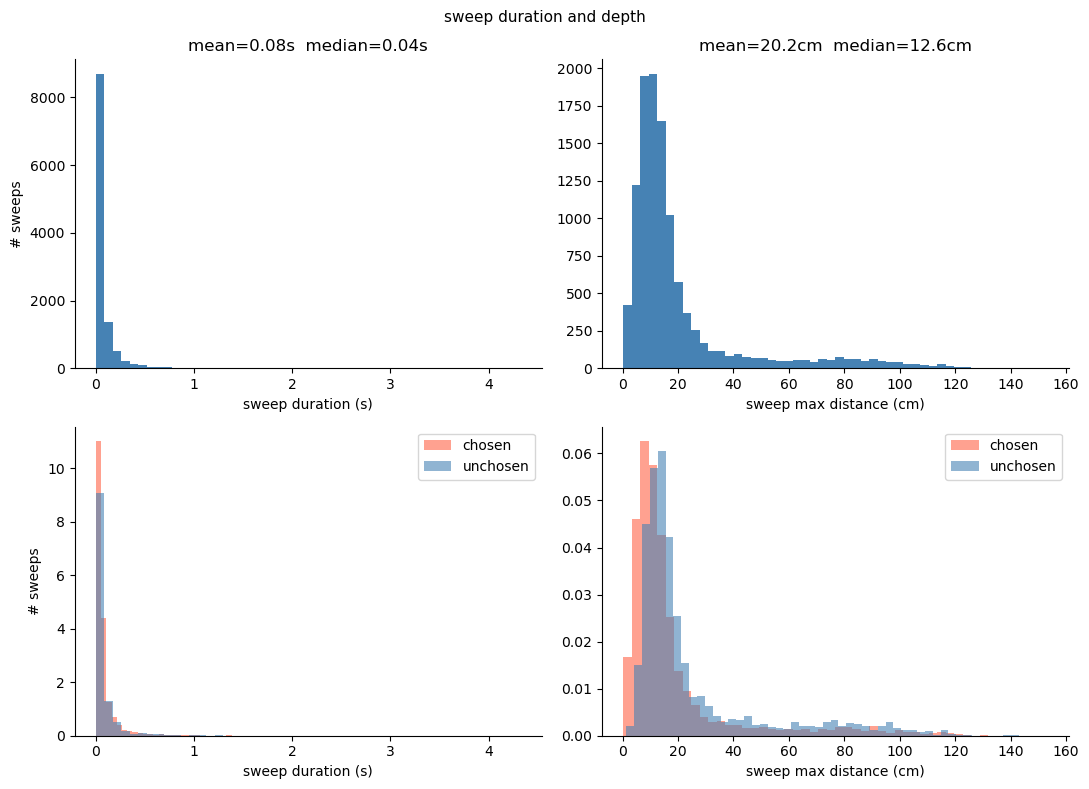

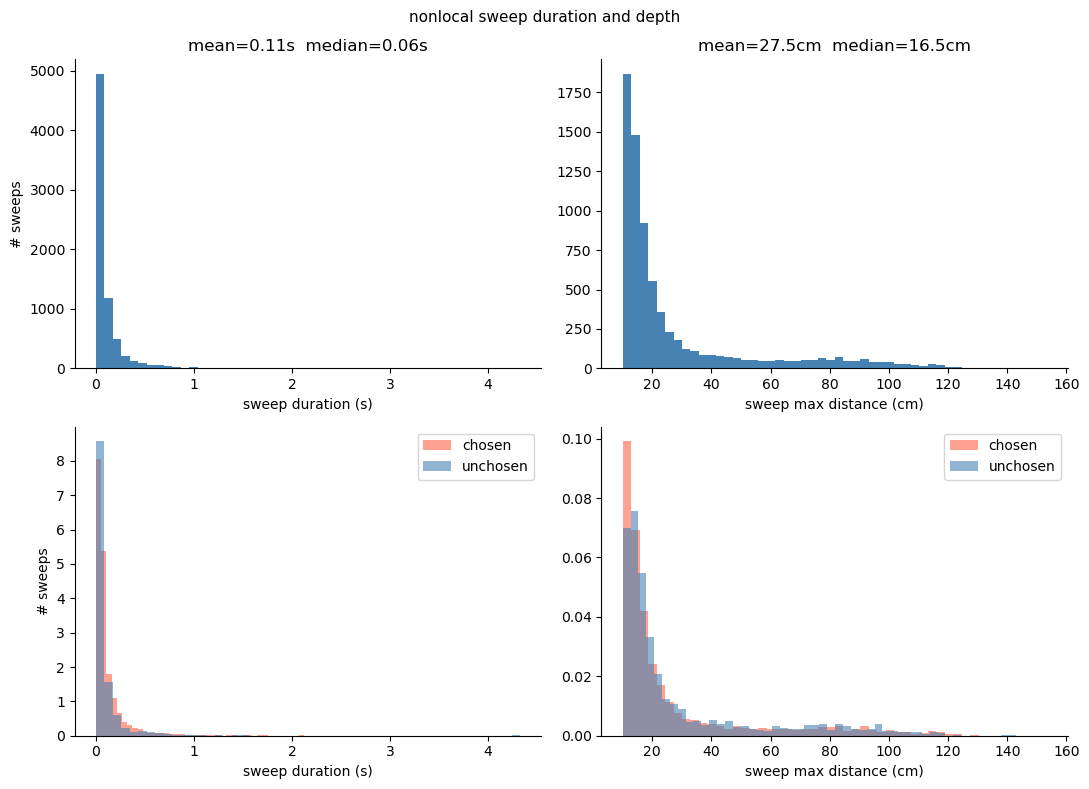

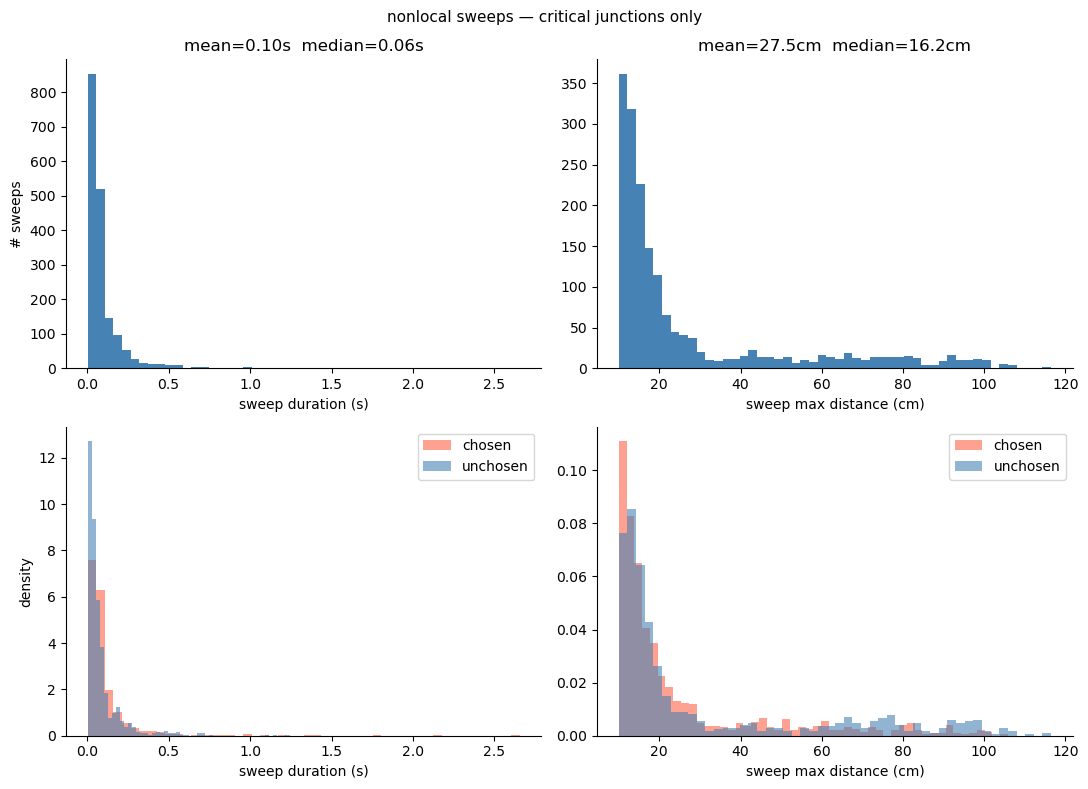

sweep_dur_s                                           \
                   count  mean   std  min   25%   50%   75%   max   
sweep_chosen                                                        
False              787.0  0.08  0.13  0.0  0.02  0.05  0.09  1.24   
True              1002.0  0.11  0.19  0.0  0.04  0.06  0.11  2.66   

             sweep_max_dist                                                    
                      count   mean    std    min    25%    50%    75%     max  
sweep_chosen                                                                   
False                 787.0  30.98  27.43  10.02  13.19  16.95  39.74  116.49  
True                 1002.0  24.69  20.47  10.01  12.30  15.84  25.91  105.85

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# ── Distributions ──────────────────────────────────────────────────────────────
axes[0, 0].hist(sweeps_df["sweep_dur_s"].dropna(), bins=50, color="steelblue", edgecolor="none")
axes[0, 0].set_xlabel("sweep duration (s)")
axes[0, 0].set_ylabel("# sweeps")
axes[0, 0].set_title(f"mean={sweeps_df['sweep_dur_s'].mean():.2f}s  median={sweeps_df['sweep_dur_s'].median():.2f}s")

axes[0, 1].hist(sweeps_df["sweep_max_dist"].dropna(), bins=50, color="steelblue", edgecolor="none")
axes[0, 1].set_xlabel("sweep max distance (cm)")
axes[0, 1].set_title(f"mean={sweeps_df['sweep_max_dist'].mean():.1f}cm  median={sweeps_df['sweep_max_dist'].median():.1f}cm")

# ── Chosen vs unchosen ─────────────────────────────────────────────────────────
for val, label, color in [(True, "chosen", "tomato"), (False, "unchosen", "steelblue")]:
    subset = sweeps_df[sweeps_df["sweep_chosen"] == val]
    axes[1, 0].hist(subset["sweep_dur_s"].dropna(), bins=50, alpha=0.6,
                    color=color, edgecolor="none", label=label, density=True)
    axes[1, 1].hist(subset["sweep_max_dist"].dropna(), bins=50, alpha=0.6,
                    color=color, edgecolor="none", label=label, density=True)

axes[1, 0].set_xlabel("sweep duration (s)")
axes[1, 0].set_ylabel("# sweeps")
axes[1, 0].legend()

axes[1, 1].set_xlabel("sweep max distance (cm)")
axes[1, 1].legend()

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("sweep duration and depth", fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary stats ──────────────────────────────────────────────────────────────
sweeps_df.groupby("sweep_chosen")[["sweep_dur_s", "sweep_max_dist"]].describe().round(2)

nonlocal_sweeps = sweeps_df[sweeps_df["is_nonlocal"]]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# ── Distributions ──────────────────────────────────────────────────────────────
axes[0, 0].hist(nonlocal_sweeps["sweep_dur_s"].dropna(), bins=50, color="steelblue", edgecolor="none")
axes[0, 0].set_xlabel("sweep duration (s)")
axes[0, 0].set_ylabel("# sweeps")
axes[0, 0].set_title(f"mean={nonlocal_sweeps['sweep_dur_s'].mean():.2f}s  median={nonlocal_sweeps['sweep_dur_s'].median():.2f}s")

axes[0, 1].hist(nonlocal_sweeps["sweep_max_dist"].dropna(), bins=50, color="steelblue", edgecolor="none")
axes[0, 1].set_xlabel("sweep max distance (cm)")
axes[0, 1].set_title(f"mean={nonlocal_sweeps['sweep_max_dist'].mean():.1f}cm  median={nonlocal_sweeps['sweep_max_dist'].median():.1f}cm")

# ── Chosen vs unchosen ─────────────────────────────────────────────────────────
for val, label, color in [(True, "chosen", "tomato"), (False, "unchosen", "steelblue")]:
    subset = nonlocal_sweeps[nonlocal_sweeps["sweep_chosen"] == val]
    axes[1, 0].hist(subset["sweep_dur_s"].dropna(), bins=50, alpha=0.6,
                    color=color, edgecolor="none", label=label, density=True)
    axes[1, 1].hist(subset["sweep_max_dist"].dropna(), bins=50, alpha=0.6,
                    color=color, edgecolor="none", label=label, density=True)

axes[1, 0].set_xlabel("sweep duration (s)")
axes[1, 0].set_ylabel("# sweeps")
axes[1, 0].legend()

axes[1, 1].set_xlabel("sweep max distance (cm)")
axes[1, 1].legend()

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("nonlocal sweep duration and depth", fontsize=11)
plt.tight_layout()
plt.show()

nonlocal_sweeps.groupby("sweep_chosen")[["sweep_dur_s", "sweep_max_dist"]].describe().round(2)

#----------------------------
nonlocal_critical = sweeps_df[sweeps_df["is_nonlocal"] & sweeps_df["is_critical"]]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# ── Distributions ──────────────────────────────────────────────────────────────
axes[0, 0].hist(nonlocal_critical["sweep_dur_s"].dropna(), bins=50, color="steelblue", edgecolor="none")
axes[0, 0].set_xlabel("sweep duration (s)")
axes[0, 0].set_ylabel("# sweeps")
axes[0, 0].set_title(f"mean={nonlocal_critical['sweep_dur_s'].mean():.2f}s  median={nonlocal_critical['sweep_dur_s'].median():.2f}s")

axes[0, 1].hist(nonlocal_critical["sweep_max_dist"].dropna(), bins=50, color="steelblue", edgecolor="none")
axes[0, 1].set_xlabel("sweep max distance (cm)")
axes[0, 1].set_title(f"mean={nonlocal_critical['sweep_max_dist'].mean():.1f}cm  median={nonlocal_critical['sweep_max_dist'].median():.1f}cm")

# ── Chosen vs unchosen ─────────────────────────────────────────────────────────
for val, label, color in [(True, "chosen", "tomato"), (False, "unchosen", "steelblue")]:
    subset = nonlocal_critical[nonlocal_critical["sweep_chosen"] == val]
    axes[1, 0].hist(subset["sweep_dur_s"].dropna(), bins=50, alpha=0.6, density=True,
                    color=color, edgecolor="none", label=label)
    axes[1, 1].hist(subset["sweep_max_dist"].dropna(), bins=50, alpha=0.6, density=True,
                    color=color, edgecolor="none", label=label)

axes[1, 0].set_xlabel("sweep duration (s)")
axes[1, 0].set_ylabel("density")
axes[1, 0].legend()

axes[1, 1].set_xlabel("sweep max distance (cm)")
axes[1, 1].legend()

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("nonlocal sweeps — critical junctions only", fontsize=11)
plt.tight_layout()
plt.show()

nonlocal_critical.groupby("sweep_chosen")[["sweep_dur_s", "sweep_max_dist"]].describe().round(2)



Blocks with ≥40 trials: 73


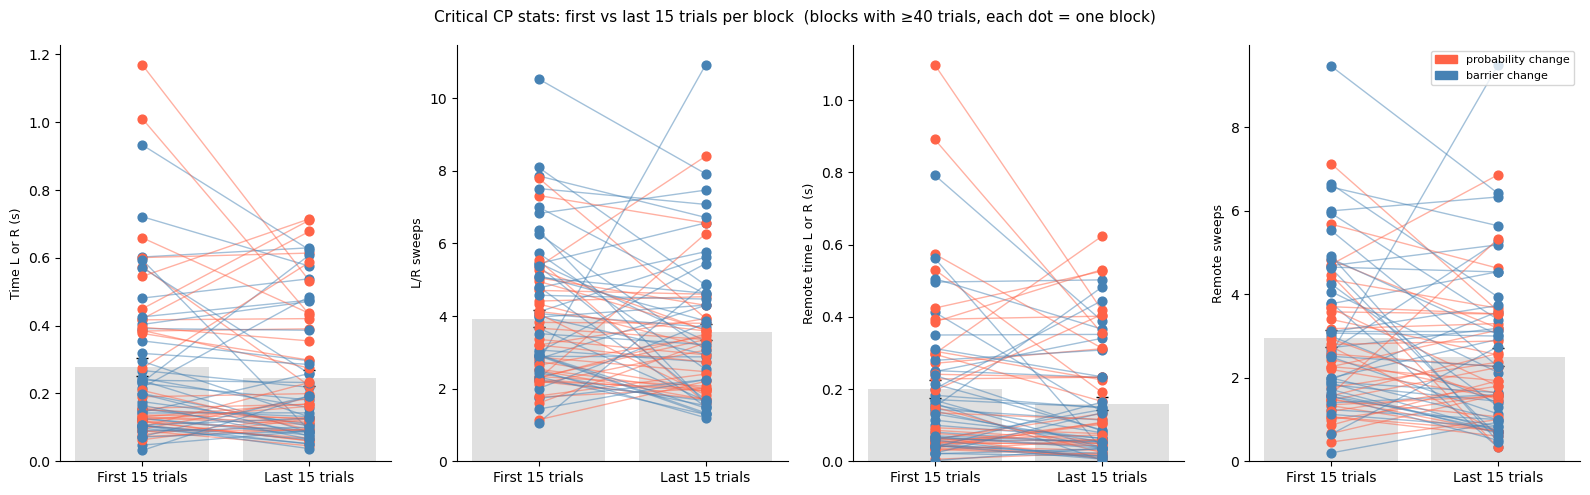

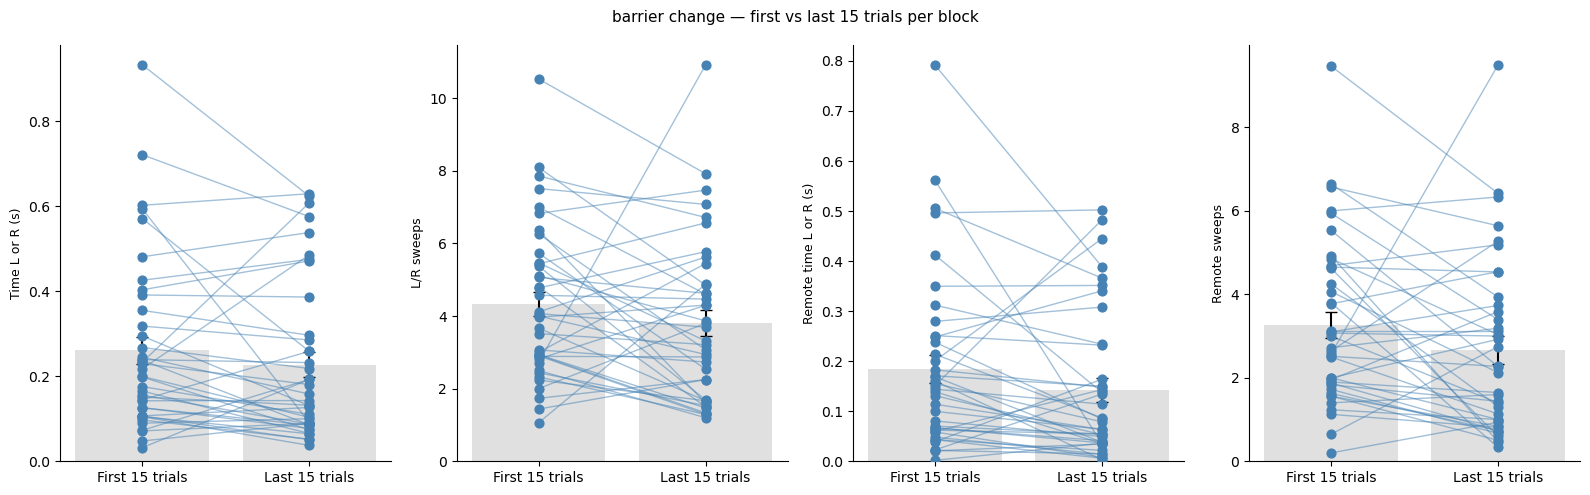

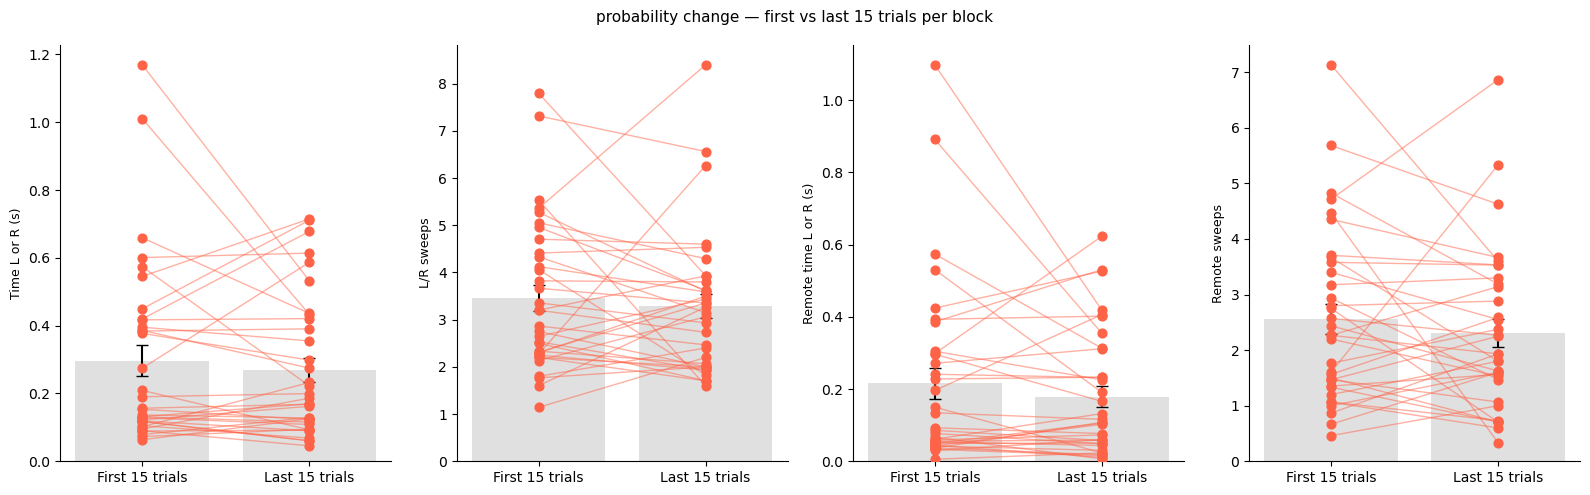

In [54]:
# ---- First vs last trials within each block ----
HALF_SIZE  = 15
MIN_TRIALS = HALF_SIZE * 2 + 10

# Fetch trial ordering for all blocks
trial_order = pd.DataFrame(
    (HexMazeBlock.Trial() & decode_keys).fetch(
        "nwb_file_name", "epoch", "block", "block_trial_num", "epoch_trial_num",
        as_dict=True
    )
)

# Fetch task type for each block
task_type_df = pd.DataFrame(
    (HexMazeBlock() & decode_keys).fetch(
        "nwb_file_name", "epoch", "block", "task_type", as_dict=True
    )
)

# For each block, find epoch_trial_nums belonging to first/last HALF_SIZE trials
block_halves = {}
for (nwb, epoch, block), grp in trial_order.groupby(["nwb_file_name", "epoch", "block"]):
    if len(grp) < MIN_TRIALS:
        continue
    sorted_etns = grp.sort_values("block_trial_num")["epoch_trial_num"].values
    block_halves[(nwb, epoch, block)] = {
        "first": set(sorted_etns[:HALF_SIZE]),
        "last":  set(sorted_etns[-HALF_SIZE:]),
    }

print(f"Blocks with ≥{MIN_TRIALS} trials: {len(block_halves)}")

# Tag each stats_df row as first/last/NaN
def _tag_half(row):
    info = block_halves.get((row["nwb_file_name"], row["epoch"], row["block"]))
    if info is None:
        return np.nan
    if row["trial"] in info["first"]:
        return f"First {HALF_SIZE} trials"
    if row["trial"] in info["last"]:
        return f"Last {HALF_SIZE} trials"
    return np.nan

stats_df["block_half"] = stats_df.apply(_tag_half, axis=1)

# Average within each (block, block_half)
half_metrics = ["time_lr_s", "nonlocal_time_lr_s", "n_lr_sweeps", "n_nonlocal_sweeps"]
block_half_means = (
    stats_df.dropna(subset=["block_half"])
    .groupby(["nwb_file_name", "epoch", "block", "block_half"])
    [half_metrics].mean().reset_index()
)

# Merge task type
block_half_means = block_half_means.merge(
    task_type_df, on=["nwb_file_name", "epoch", "block"], how="left"
)

# Build session label
block_half_means["session_label"] = (
    block_half_means["nwb_file_name"].str.replace(r"\.nwb$", "", regex=True)
    + "  ep" + block_half_means["epoch"].astype(str)
    + "  b"  + block_half_means["block"].astype(str)
)
block_keys_sorted = block_half_means["session_label"].unique()

task_colors = {"probability change": "tomato", "barrier change": "steelblue"}

half_labels = [f"First {HALF_SIZE} trials", f"Last {HALF_SIZE} trials"]
half_metric_labels = [
    ("time_lr_s",          "Time L or R (s)"),
    ("n_lr_sweeps",        "L/R sweeps"),
    ("nonlocal_time_lr_s", "Remote time L or R (s)"),
    ("n_nonlocal_sweeps",  "Remote sweeps"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, ylabel) in zip(axes, half_metric_labels):
    # Overall mean ± SEM bars
    for x, half in enumerate(half_labels):
        vals = block_half_means[block_half_means["block_half"] == half][metric].dropna()
        ax.bar(x, vals.mean(), yerr=np.nan_to_num(vals.sem(), nan=0),
               color="lightgray", capsize=4, alpha=0.7, zorder=1)

    # Dots and lines per block, colored by task type
    for sess in block_keys_sorted:
        rows = block_half_means[block_half_means["session_label"] == sess]
        color = task_colors.get(rows["task_type"].iloc[0], "gray")
        pts = rows.set_index("block_half").reindex(half_labels)
        ax.plot(range(len(half_labels)), pts[metric].values,
                color=color, alpha=0.5, linewidth=1, zorder=2)
        ax.scatter(range(len(half_labels)), pts[metric].values,
                   color=color, s=40, zorder=3)

    ax.set_xticks(range(len(half_labels)))
    ax.set_xticklabels(half_labels)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Legend for task type
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=l) for l, c in task_colors.items()]
axes[-1].legend(handles=handles, fontsize=8, loc="upper right")

fig.suptitle(
    f"Critical CP stats: first vs last {HALF_SIZE} trials per block  "
    f"(blocks with ≥{MIN_TRIALS} trials, each dot = one block)",
    fontsize=11
)
plt.tight_layout()
plt.show()

# Do separate plots for barrier and prob
for task_type, group_df in block_half_means.groupby("task_type"):
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))

    for ax, (metric, ylabel) in zip(axes, half_metric_labels):
        # Overall mean ± SEM bars
        for x, half in enumerate(half_labels):
            vals = group_df[group_df["block_half"] == half][metric].dropna()
            ax.bar(x, vals.mean(), yerr=np.nan_to_num(vals.sem(), nan=0),
                   color="lightgray", capsize=4, alpha=0.7, zorder=1)

        # Dots and lines per block
        for sess in group_df["session_label"].unique():
            rows = group_df[group_df["session_label"] == sess]
            color = task_colors[task_type]
            pts = rows.set_index("block_half").reindex(half_labels)
            ax.plot(range(len(half_labels)), pts[metric].values,
                    color=color, alpha=0.5, linewidth=1, zorder=2)
            ax.scatter(range(len(half_labels)), pts[metric].values,
                       color=color, s=40, zorder=3)

        ax.set_xticks(range(len(half_labels)))
        ax.set_xticklabels(half_labels)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"{task_type} — first vs last {HALF_SIZE} trials per block",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()


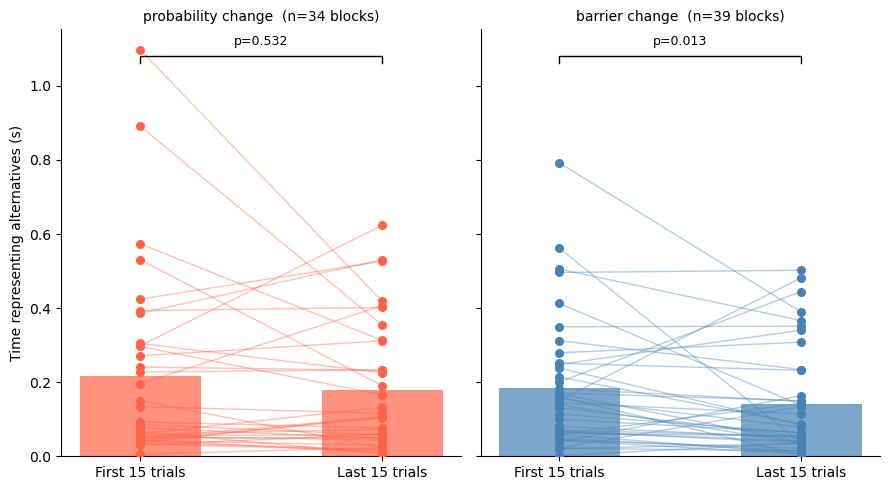

probability change  (n=34 blocks)
  first: 0.216 ± 0.043
  last:  0.179 ± 0.030
  delta: -0.037 ± 0.032
  Wilcoxon: T=260.00  p=0.532  ns

barrier change  (n=39 blocks)
  first: 0.184 ± 0.028
  last:  0.142 ± 0.023
  delta: -0.042 ± 0.023
  Wilcoxon: T=214.00  p=0.013  *

Barrier vs prob change delta — Mann-Whitney: U=801.00  p=0.128  ns


In [55]:
from scipy import stats
import matplotlib.patches as mpatches

def _significance_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

# ── Compute stats first so we can annotate the plot ───────────────────────────
wilcoxon_results = {}
deltas = {}
for task_type in task_colors:
    subset = block_half_means[block_half_means["task_type"] == task_type]
    first = subset[subset["block_half"] == f"First {HALF_SIZE} trials"].set_index("session_label")["nonlocal_time_lr_s"]
    last  = subset[subset["block_half"] == f"Last {HALF_SIZE} trials"].set_index("session_label")["nonlocal_time_lr_s"]
    common = first.index.intersection(last.index)
    first, last = first.loc[common], last.loc[common]
    T, p = stats.wilcoxon(first, last)
    wilcoxon_results[task_type] = {"first": first, "last": last, "T": T, "p": p, "n": len(common)}
    deltas[task_type] = (last - first).values

U, p_mw = stats.mannwhitneyu(*deltas.values(), alternative="two-sided")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
x = np.arange(len(half_labels))
bar_width = 0.5

for ax, (task_type, color) in zip(axes, task_colors.items()):
    res = wilcoxon_results[task_type]

    # Bars
    means = [res["first"].mean(), res["last"].mean()]
    sems  = [res["first"].sem(),  res["last"].sem()]
    ax.bar(x, means, bar_width, color=color, alpha=0.7, capsize=4, zorder=1)

    # Dots and lines per block
    for sess in block_half_means[block_half_means["task_type"] == task_type]["session_label"].unique():
        rows = block_half_means[block_half_means["session_label"] == sess]
        pts  = rows.set_index("block_half").reindex(half_labels)
        ax.plot(x, pts["nonlocal_time_lr_s"].values,
                color=color, alpha=0.4, linewidth=1, zorder=2)
        ax.scatter(x, pts["nonlocal_time_lr_s"].values,
                   color=color, s=30, zorder=3)

    # Significance bracket
    y_max = ax.get_ylim()[1] * 0.92
    ax.plot([x[0], x[0], x[1], x[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max],
            color="k", linewidth=1)
    ax.text(np.mean(x), y_max * 1.04, f"p={res['p']:.3f}",
        ha="center", va="bottom", fontsize=9)


    ax.set_xticks(x)
    ax.set_xticklabels(half_labels)
    ax.set_title(f"{task_type}  (n={res['n']} blocks)", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Time representing alternatives (s)", fontsize=10)

# fig.suptitle(
#     f"Remote L/R time: first vs last {HALF_SIZE} trials per block\n"
#     f"barrier vs prob change delta — Mann-Whitney p={p_mw:.3f} ({_significance_stars(p_mw)})",
#     fontsize=10
# )
plt.tight_layout()
plt.show()

# ── Print summary ──────────────────────────────────────────────────────────────
for task_type, res in wilcoxon_results.items():
    delta = res["last"] - res["first"]
    print(f"{task_type}  (n={res['n']} blocks)")
    print(f"  first: {res['first'].mean():.3f} ± {res['first'].sem():.3f}")
    print(f"  last:  {res['last'].mean():.3f} ± {res['last'].sem():.3f}")
    print(f"  delta: {delta.mean():.3f} ± {delta.sem():.3f}")
    print(f"  Wilcoxon: T={res['T']:.2f}  p={res['p']:.3f}  {_significance_stars(res['p'])}")
    print()
print(f"Barrier vs prob change delta — Mann-Whitney: U={U:.2f}  p={p_mw:.3f}  {_significance_stars(p_mw)}")



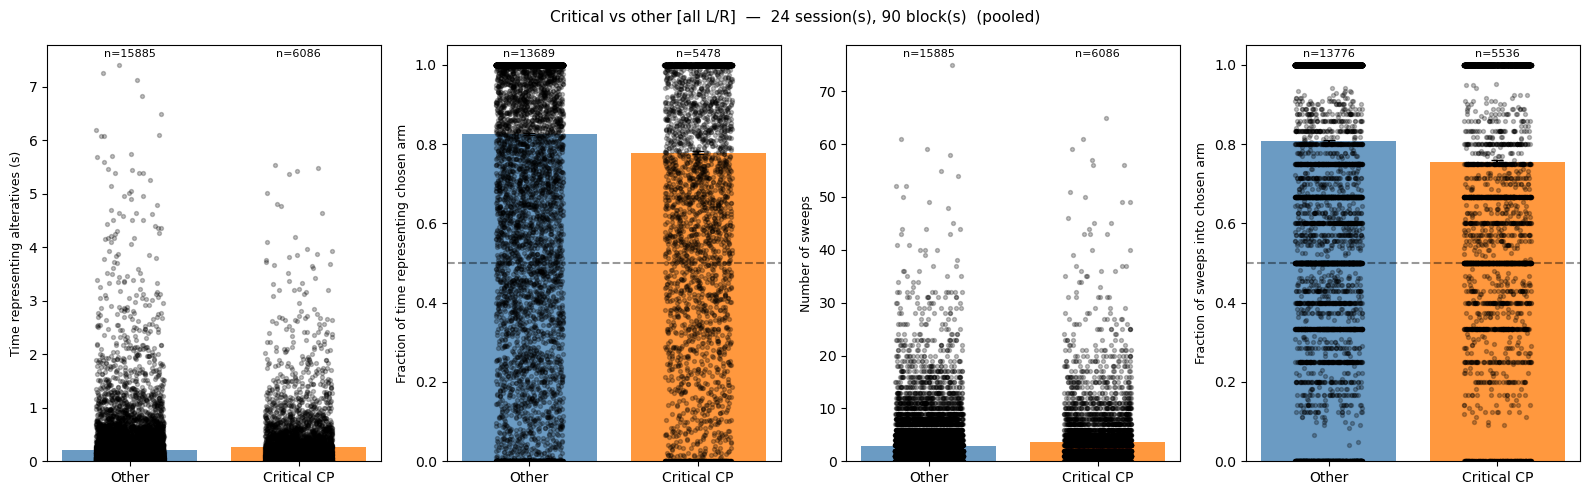

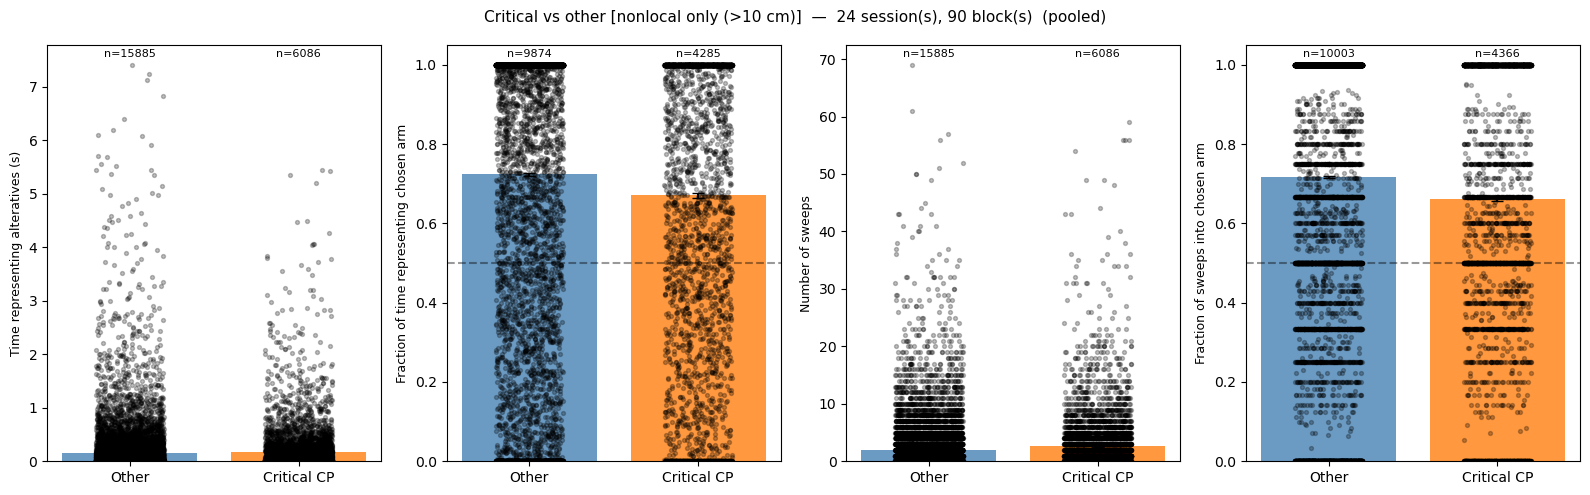

In [56]:
# ---- Critical vs non-critical junctions — pooled across all sessions/blocks ----

prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}
n_sessions = len(all_stats_df[["nwb_file_name", "epoch"]].drop_duplicates())
n_blocks = all_stats_df.groupby(["nwb_file_name", "epoch", "block"]).ngroups

for metrics, label in [
    ([("time_lr_s", "Time representing alteratives (s)"), ("prop_chosen", "Fraction of time representing chosen arm"),
      ("n_lr_sweeps", "Number of sweeps"),    ("frac_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "all L/R"),
    ([("nonlocal_time_lr_s", "Time representing alteratives (s)"), 
      ("prop_nonlocal_chosen", "Fraction of time representing chosen arm"),
      ("n_nonlocal_sweeps",  "Number of sweeps"),           
      ("frac_nonlocal_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        for x, (is_crit, color) in enumerate([(False, "steelblue"), (True, "tab:orange")]):
            vals = all_stats_df[all_stats_df["is_critical"] == is_crit][metric].dropna()
            ax.bar(x, vals.mean(), yerr=vals.sem(), color=color, capsize=4, alpha=0.8)
            ax.scatter(np.full(len(vals), x) + np.random.uniform(-0.2, 0.2, len(vals)),
                       vals, color="k", s=8, alpha=0.25, zorder=3)
        if metric in prop_metrics:
            ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Other", "Critical CP"])
        ax.set_ylabel(ylabel, fontsize=9)
        ymax = ax.get_ylim()[1]
        for x, is_crit in enumerate([False, True]):
            n = all_stats_df[all_stats_df["is_critical"] == is_crit][metric].dropna().shape[0]
            ax.text(x, ymax * 0.97, f"n={n}", ha="center", fontsize=8)
    fig.suptitle(
        f"Critical vs other [{label}]  —  {n_sessions} session(s), {n_blocks} block(s)  (pooled)",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

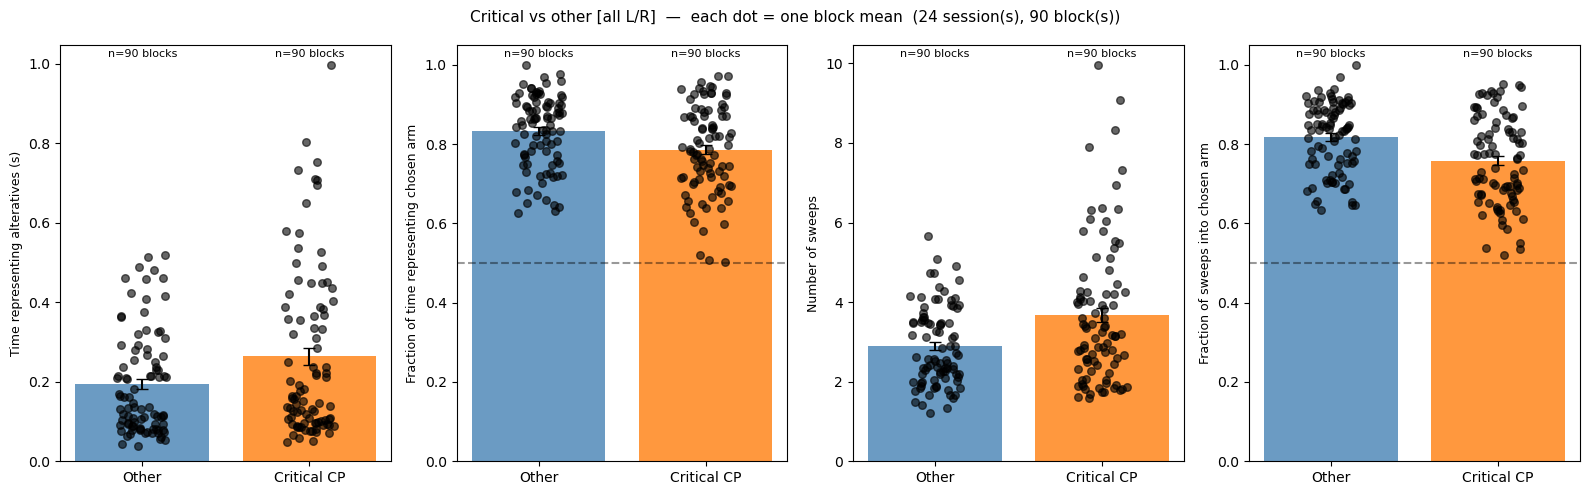

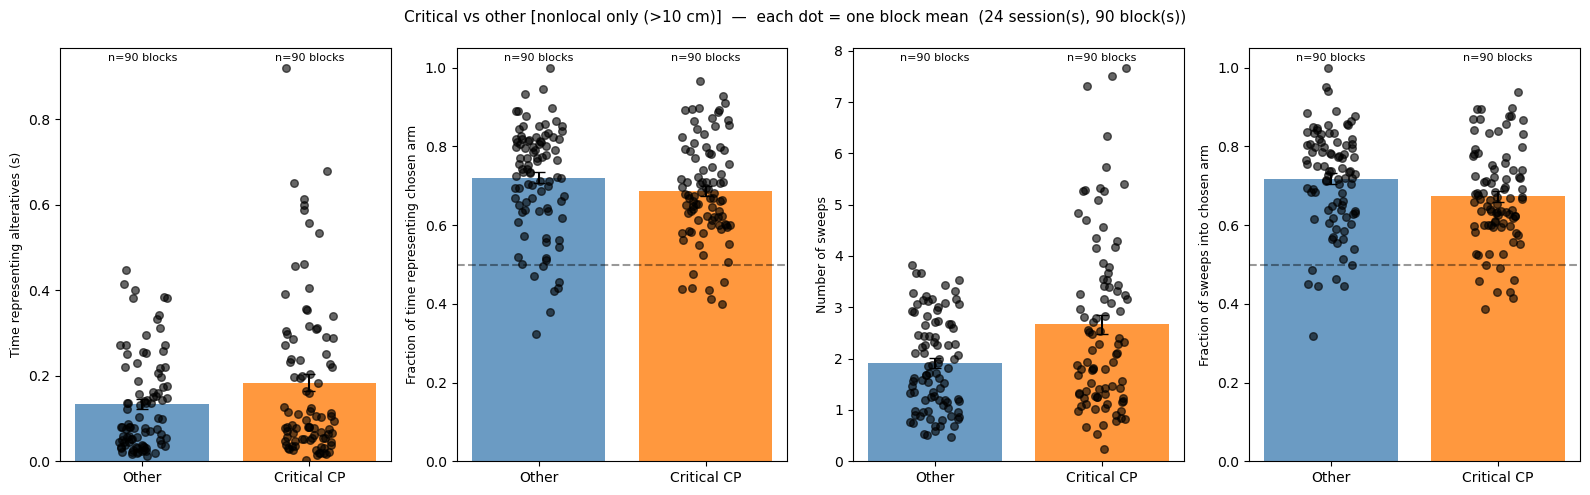

In [57]:
# ---- Critical vs other: each dot = one block mean ----

all_metric_cols = ["time_lr_s", "nonlocal_time_lr_s", "prop_chosen", "prop_nonlocal_chosen",
                   "n_lr_sweeps", "n_nonlocal_sweeps", "frac_sweeps_chosen", "frac_nonlocal_sweeps_chosen"]
prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}

block_means_crit = (
    all_stats_df
    .groupby(["nwb_file_name", "epoch", "block", "is_critical"])
    [all_metric_cols].mean().reset_index()
)

n_sessions = len(all_stats_df[["nwb_file_name", "epoch"]].drop_duplicates())
n_blocks = all_stats_df.groupby(["nwb_file_name", "epoch", "block"]).ngroups

for metrics, label in [
    ([("time_lr_s", "Time representing alteratives (s)"), 
      ("prop_chosen", "Fraction of time representing chosen arm"),
      ("n_lr_sweeps", "Number of sweeps"),    
      ("frac_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "all L/R"),
    ([("nonlocal_time_lr_s", "Time representing alteratives (s)"), 
      ("prop_nonlocal_chosen", "Fraction of time representing chosen arm"),
      ("n_nonlocal_sweeps",  "Number of sweeps"),           
      ("frac_nonlocal_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        for x, (is_crit, color) in enumerate([(False, "steelblue"), (True, "tab:orange")]):
            vals = block_means_crit[block_means_crit["is_critical"] == is_crit][metric].dropna()
            ax.bar(x, vals.mean(), yerr=vals.sem(), color=color, capsize=4, alpha=0.8)
            ax.scatter(np.full(len(vals), x) + np.random.uniform(-0.15, 0.15, len(vals)),
                       vals, color="k", s=30, alpha=0.6, zorder=3)
        if metric in prop_metrics:
            ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Other", "Critical CP"])
        ax.set_ylabel(ylabel, fontsize=9)
        ymax = ax.get_ylim()[1]
        for x, is_crit in enumerate([False, True]):
            n = block_means_crit[block_means_crit["is_critical"] == is_crit][metric].dropna().shape[0]
            ax.text(x, ymax * 0.97, f"n={n} blocks", ha="center", fontsize=8)
    fig.suptitle(
        f"Critical vs other [{label}]  —  each dot = one block mean  ({n_sessions} session(s), {n_blocks} block(s))",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

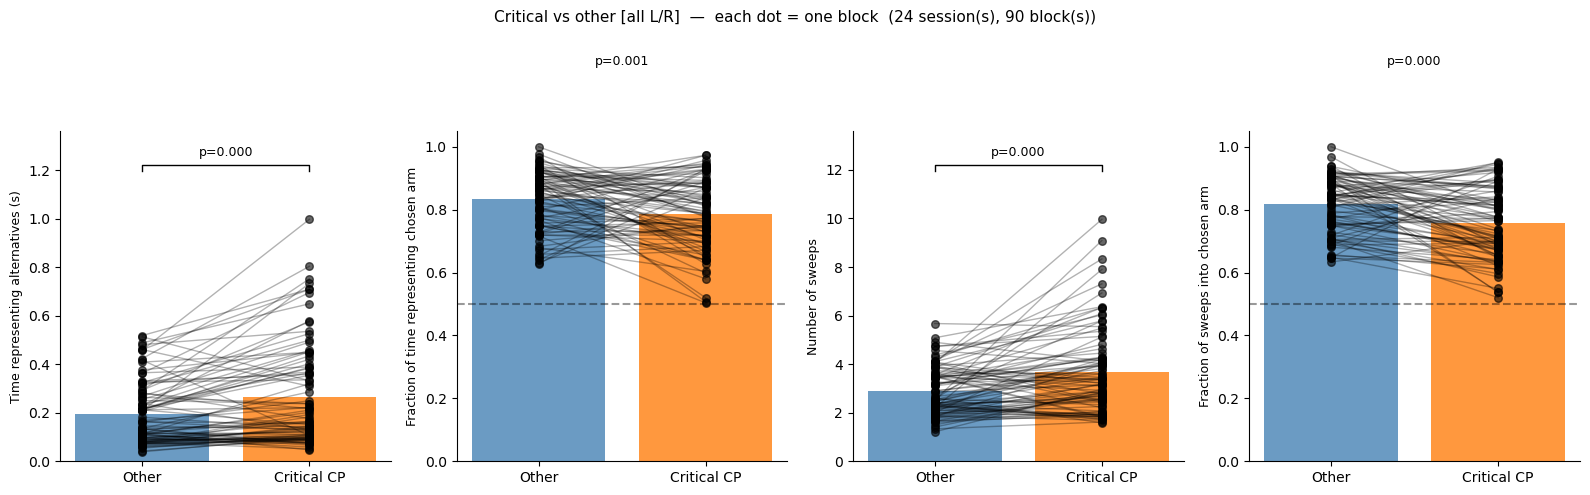

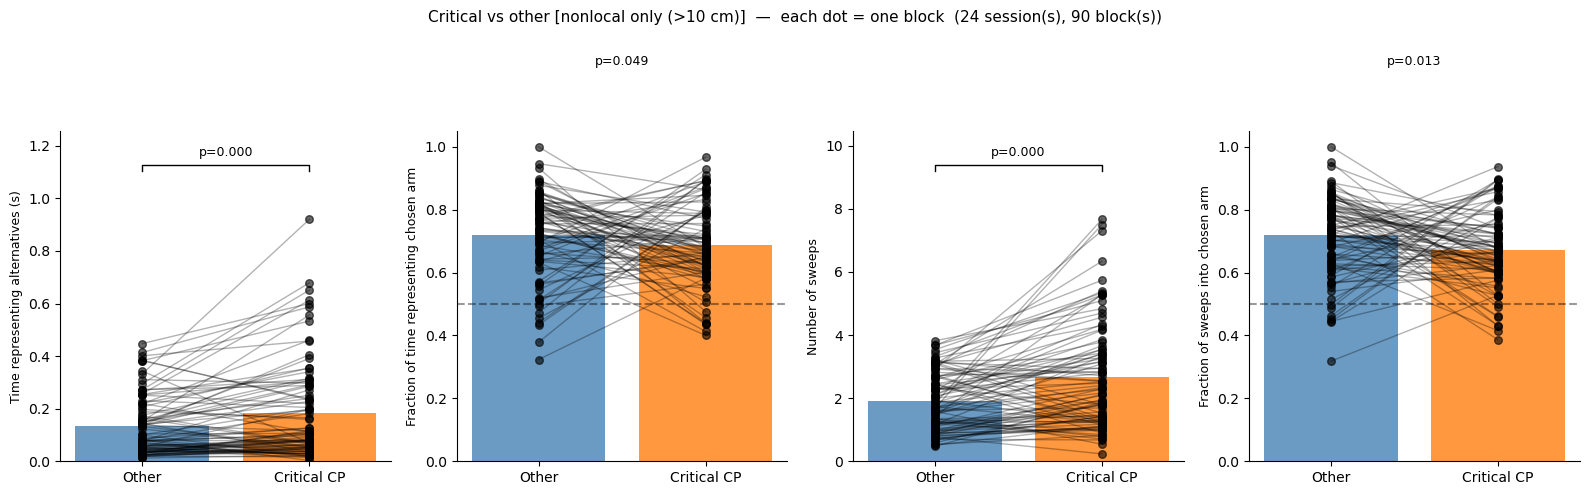

In [58]:
# ---- Critical vs other: each dot = one block mean ----

all_metric_cols = ["time_lr_s", "nonlocal_time_lr_s", "prop_chosen", "prop_nonlocal_chosen",
                   "n_lr_sweeps", "n_nonlocal_sweeps", "frac_sweeps_chosen", "frac_nonlocal_sweeps_chosen"]
prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}

block_means_crit = (
    all_stats_df
    .groupby(["nwb_file_name", "epoch", "block", "is_critical"])
    [all_metric_cols].mean().reset_index()
)

n_sessions = len(all_stats_df[["nwb_file_name", "epoch"]].drop_duplicates())
n_blocks = all_stats_df.groupby(["nwb_file_name", "epoch", "block"]).ngroups

for metrics, label in [
    ([("time_lr_s", "Time representing alternatives (s)"),
      ("prop_chosen", "Fraction of time representing chosen arm"),
      ("n_lr_sweeps", "Number of sweeps"),
      ("frac_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "all L/R"),
    ([("nonlocal_time_lr_s", "Time representing alternatives (s)"),
      ("prop_nonlocal_chosen", "Fraction of time representing chosen arm"),
      ("n_nonlocal_sweeps",  "Number of sweeps"),
      ("frac_nonlocal_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        # Bars
        for x, (is_crit, color) in enumerate([(False, "steelblue"), (True, "tab:orange")]):
            vals = block_means_crit[block_means_crit["is_critical"] == is_crit][metric].dropna()
            ax.bar(x, vals.mean(), color=color, capsize=4, alpha=0.8, zorder=1)

        # Paired dots and lines per block
        paired = block_means_crit.pivot_table(
            index=["nwb_file_name", "epoch", "block"], columns="is_critical", values=metric
        ).dropna()
        ax.scatter(np.zeros(len(paired)), paired[False], color="k", s=30, alpha=0.6, zorder=3)
        ax.scatter(np.ones(len(paired)),  paired[True],  color="k", s=30, alpha=0.6, zorder=3)
        for _, row in paired.iterrows():
            ax.plot([0, 1], [row[False], row[True]],
                    color="k", alpha=0.3, linewidth=1, zorder=2)

        # Paired Wilcoxon
        if len(paired) >= 2:
            _, p = stats.wilcoxon(paired[False], paired[True])
        else:
            p = np.nan

        # Significance bracket
        ax.set_ylim(top=ax.get_ylim()[1] * 1.3)
        ymax = ax.get_ylim()[1]
        bracket_y = ymax * 0.88
        ax.plot([0, 0, 1, 1], [bracket_y, bracket_y * 1.02, bracket_y * 1.02, bracket_y],
                color="k", linewidth=1)
        ax.text(0.5, bracket_y * 1.04, f"p={p:.3f}" if not np.isnan(p) else "",
                ha="center", va="bottom", fontsize=9)

        if metric in prop_metrics:
            ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Other", "Critical CP"])
        ax.set_ylabel(ylabel, fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"Critical vs other [{label}]  —  each dot = one block  ({n_sessions} session(s), {n_blocks} block(s))",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()


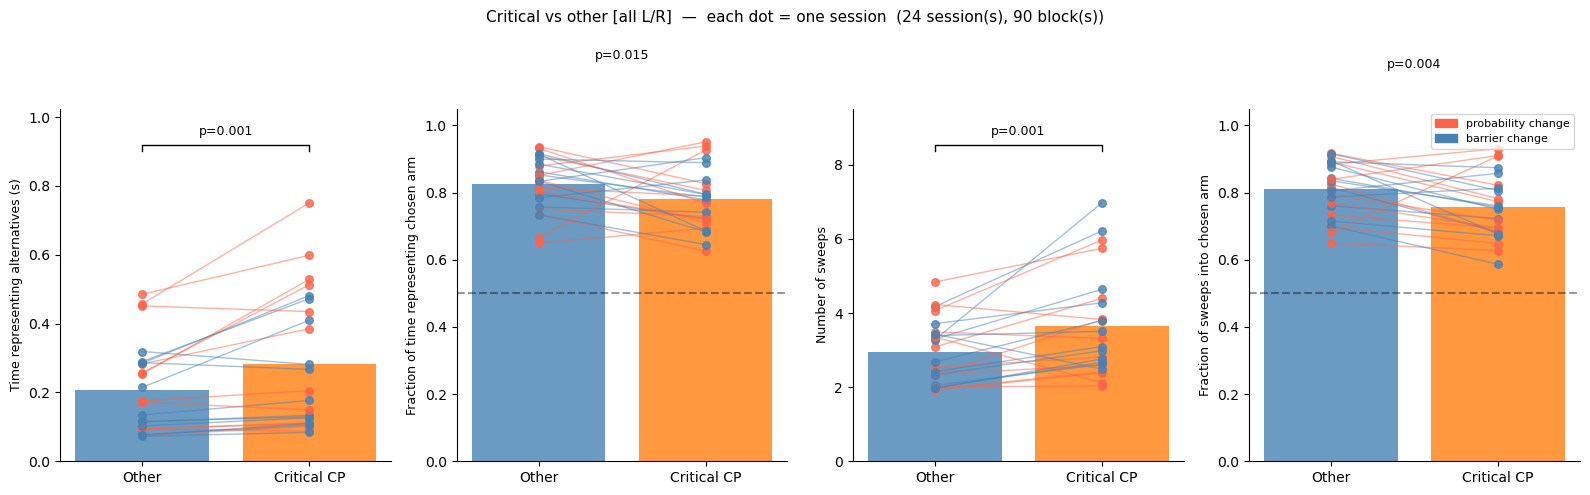

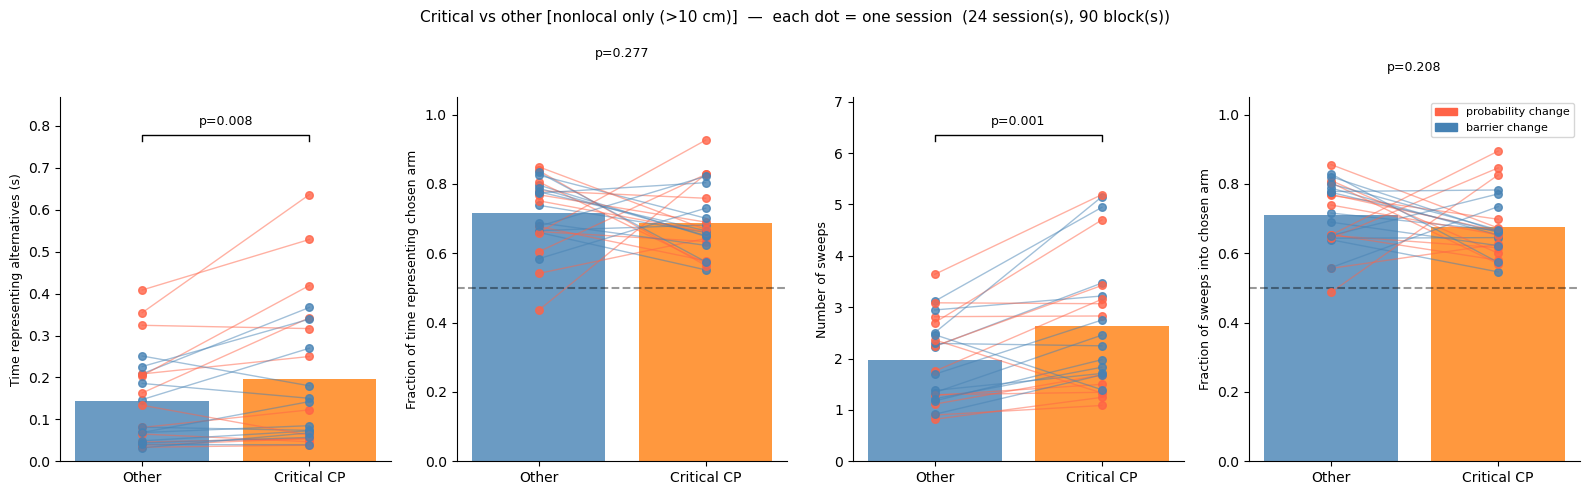

In [59]:
# ---- Critical vs other: each dot = one session mean ----

import matplotlib.patches as mpatches

session_means_crit = (
    all_stats_df
    .groupby(["nwb_file_name", "epoch", "is_critical"])
    [all_metric_cols].mean().reset_index()
)

# Merge task type for coloring
session_means_crit = session_means_crit.merge(
    task_type_df.groupby(["nwb_file_name", "epoch"])["task_type"].agg(
        lambda x: x.mode()[0]
    ).reset_index(),
    on=["nwb_file_name", "epoch"], how="left"
)

n_sessions = len(all_stats_df[["nwb_file_name", "epoch"]].drop_duplicates())
n_blocks = all_stats_df.groupby(["nwb_file_name", "epoch", "block"]).ngroups

for metrics, label in [
    ([("time_lr_s", "Time representing alternatives (s)"),
      ("prop_chosen", "Fraction of time representing chosen arm"),
      ("n_lr_sweeps", "Number of sweeps"),
      ("frac_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "all L/R"),
    ([("nonlocal_time_lr_s", "Time representing alternatives (s)"),
      ("prop_nonlocal_chosen", "Fraction of time representing chosen arm"),
      ("n_nonlocal_sweeps",  "Number of sweeps"),
      ("frac_nonlocal_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        # Bars
        for x, (is_crit, color) in enumerate([(False, "steelblue"), (True, "tab:orange")]):
            vals = session_means_crit[session_means_crit["is_critical"] == is_crit][metric].dropna()
            ax.bar(x, vals.mean(), color=color, alpha=0.8, zorder=1)

        # Paired dots and lines per session, colored by task type
        paired = session_means_crit.pivot_table(
            index=["nwb_file_name", "epoch"], columns="is_critical", values=metric
        ).dropna()
        for (nwb, epoch), row in paired.iterrows():
            tt = session_means_crit[
                (session_means_crit["nwb_file_name"] == nwb) &
                (session_means_crit["epoch"] == epoch)
            ]["task_type"].iloc[0]
            color = task_colors.get(tt, "gray")
            ax.plot([0, 1], [row[False], row[True]],
                    color=color, alpha=0.5, linewidth=1, zorder=2)
            ax.scatter([0, 1], [row[False], row[True]],
                       color=color, s=30, alpha=0.8, zorder=3)

        # Paired Wilcoxon
        if len(paired) >= 2:
            _, p = stats.wilcoxon(paired[False], paired[True])
        else:
            p = np.nan

        # Significance bracket
        ax.set_ylim(top=ax.get_ylim()[1] * 1.3)
        ymax = ax.get_ylim()[1]
        bracket_y = ymax * 0.88
        ax.plot([0, 0, 1, 1], [bracket_y, bracket_y * 1.02, bracket_y * 1.02, bracket_y],
                color="k", linewidth=1)
        ax.text(0.5, bracket_y * 1.04, f"p={p:.3f}" if not np.isnan(p) else "",
                ha="center", va="bottom", fontsize=9)

        if metric in prop_metrics:
            ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Other", "Critical CP"])
        ax.set_ylabel(ylabel, fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    handles = [mpatches.Patch(color=c, label=l) for l, c in task_colors.items()]
    axes[-1].legend(handles=handles, fontsize=8)
    fig.suptitle(
        f"Critical vs other [{label}]  —  each dot = one session  ({n_sessions} session(s), {n_blocks} block(s))",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()


## Choice difficulty at critical CPs

**Conflict** = the higher-probability arm also requires the longer path (reward vs effort tradeoff).
Defined per trial from `HexMazeChoice`: `conflict` is True when `sign(reward_prob_diff) == sign(path_length_diff)`,
i.e. the rat had to choose between better reward and shorter path.

In [60]:
# ---- Merge HexMazeChoice difficulty info into stats_df ----
# Join HexMazeChoice with HexMazeBlock.Trial to get epoch_trial_num for the merge.

choice_rows = (HexMazeChoice() * HexMazeBlock.Trial() & decode_keys).fetch(
    "nwb_file_name", "epoch", "block", "epoch_trial_num",
    "reward_prob_diff", "path_length_diff",
    "reward_prob_chosen", "reward_prob_unchosen",
    "path_length_chosen", "path_length_unchosen",
    as_dict=True
)
choice_df = pd.DataFrame(choice_rows)

# Conflict = higher-prob arm is also the longer path
choice_df["conflict"] = choice_df["reward_prob_diff"] * choice_df["path_length_diff"] > 0

# Also keep prob_diff magnitude and whether the rat chose the high-prob arm
choice_df["chose_high_prob"] = choice_df["reward_prob_diff"] > 0
choice_df["abs_prob_diff"] = choice_df["reward_prob_diff"].abs()
choice_df["abs_path_diff"] = choice_df["path_length_diff"].abs()

# Drop choice columns if already merged (safe to re-run)
choice_cols = ["conflict", "chose_high_prob", "reward_prob_diff", "path_length_diff",
               "abs_prob_diff", "abs_path_diff", "reward_prob_chosen", "reward_prob_unchosen"]
stats_df = stats_df.drop(columns=[c for c in choice_cols if c in stats_df.columns])

stats_df = stats_df.merge(
    choice_df[["nwb_file_name", "epoch", "block", "epoch_trial_num",
               "conflict", "chose_high_prob",
               "reward_prob_diff", "path_length_diff",
               "abs_prob_diff", "abs_path_diff",
               "reward_prob_chosen", "reward_prob_unchosen"]],
    left_on=["nwb_file_name", "epoch", "block", "trial"],
    right_on=["nwb_file_name", "epoch", "block", "epoch_trial_num"],
    how="left"
).drop(columns="epoch_trial_num")

n_matched = stats_df["conflict"].notna().sum()
print(f"Visits with conflict info: {n_matched} / {len(stats_df)}")
print(f"  conflict:    {stats_df['conflict'].sum():.0f}")
print(f"  no conflict: {(stats_df['conflict'] == False).sum():.0f}")
display(stats_df[["trial", "junction", "rat_direction", "conflict", "chose_high_prob",
                  "reward_prob_diff", "path_length_diff", "n_lr_sweeps", "prop_chosen"]].head(10))

Visits with conflict info: 6084 / 6086
  conflict:    3392
  no conflict: 2692


,trial,junction,rat_direction,conflict,chose_high_prob,reward_prob_diff,path_length_diff,n_lr_sweeps,prop_chosen
0,2,25,right,False,False,-80.0,0.0,2,1.000000
1,2,21,left,False,False,-80.0,0.0,4,0.056716
2,2,31,right,False,False,-80.0,0.0,4,0.765432
3,3,31,right,False,False,-40.0,2.0,6,0.714483
4,3,25,right,False,False,-40.0,2.0,10,0.152620
5,4,25,right,False,True,80.0,0.0,0,NaN
6,4,25,right,False,True,80.0,0.0,1,0.000000
7,4,25,left,False,True,80.0,0.0,44,0.652271
8,4,21,left,False,True,80.0,0.0,3,0.592287
9,4,21,left,False,True,80.0,0.0,2,0.988095


In [61]:
# ---- Add high-prob metrics (all and remote) ----
# If rat chose the high-prob arm: high-prob direction = chosen direction, no flip.
# If rat chose the low-prob arm: high-prob direction = other side, so flip (1 - value).

for chosen_col, high_col in [
    ("prop_chosen",               "prop_high_prob"),
    ("prop_nonlocal_chosen",        "prop_nonlocal_high_prob"),
    ("frac_sweeps_chosen",        "frac_sweeps_high_prob"),
    ("frac_nonlocal_sweeps_chosen", "frac_nonlocal_sweeps_high_prob"),
]:
    stats_df[high_col] = np.where(
        stats_df["chose_high_prob"],
        stats_df[chosen_col],
        1 - stats_df[chosen_col]
    )
    # NaN when reward probs are equal (no meaningful high-prob direction)
    stats_df.loc[stats_df["reward_prob_diff"] == 0, high_col] = np.nan

print(f"Visits with high-prob metrics: {stats_df['prop_high_prob'].notna().sum()}")
display(stats_df[[
    "trial", "junction", "chose_high_prob",
    "time_lr_s", "nonlocal_time_lr_s",
    "prop_chosen", "prop_nonlocal_chosen",
    "prop_high_prob", "prop_nonlocal_high_prob",
    "n_lr_sweeps", "n_nonlocal_sweeps",
    "frac_sweeps_chosen", "frac_nonlocal_sweeps_chosen",
    "frac_sweeps_high_prob", "frac_nonlocal_sweeps_high_prob",
]].head(10))

Visits with high-prob metrics: 5478


,trial,junction,chose_high_prob,time_lr_s,nonlocal_time_lr_s,prop_chosen,prop_nonlocal_chosen,prop_high_prob,prop_nonlocal_high_prob,n_lr_sweeps,n_nonlocal_sweeps,frac_sweeps_chosen,frac_nonlocal_sweeps_chosen,frac_sweeps_high_prob,frac_nonlocal_sweeps_high_prob
0,2,25,False,0.082000,0.068000,1.000000,1.000000,0.000000,0.000000,2,2,1.000000,1.000000,0.000000,0.000000
1,2,21,False,0.670000,0.580000,0.056716,0.000000,0.943284,1.000000,4,3,0.250000,0.000000,0.750000,1.000000
2,2,31,False,0.648000,0.350000,0.765432,0.571429,0.234568,0.428571,4,4,0.750000,0.750000,0.250000,0.250000
3,3,31,False,1.450000,1.440000,0.714483,0.719444,0.285517,0.280556,6,6,0.333333,0.333333,0.666667,0.666667
4,3,25,False,1.756000,1.582000,0.152620,0.061947,0.847380,0.938053,10,5,0.600000,0.200000,0.400000,0.800000
5,4,25,True,0.000000,0.000000,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN
6,4,25,True,0.728000,0.728000,0.000000,0.000000,0.000000,0.000000,1,1,0.000000,0.000000,0.000000,0.000000
7,4,25,True,5.371999,5.357999,0.652271,0.651362,0.652271,0.651362,44,44,0.454545,0.454545,0.454545,0.454545
8,4,21,True,0.726000,0.608000,0.592287,0.569079,0.592287,0.569079,3,3,0.333333,0.333333,0.333333,0.333333
9,4,21,True,0.168000,0.046000,0.988095,0.956522,0.988095,0.956522,2,2,0.500000,0.500000,0.500000,0.500000


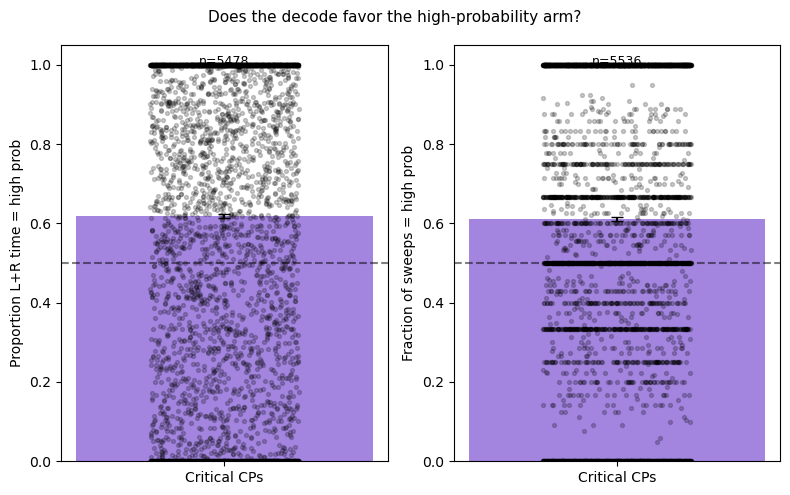

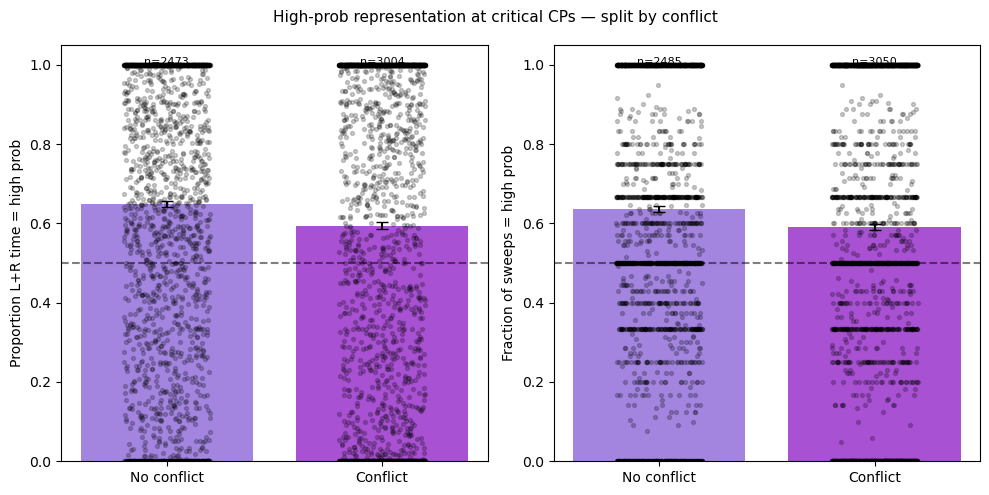

In [62]:
# ---- Proportion of time / sweeps representing the HIGH-PROB option — each dot = one visit ----

hp_metrics = [
    ("prop_high_prob",       "Proportion L+R time = high prob"),
    ("frac_sweeps_high_prob", "Fraction of sweeps = high prob"),
]

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

for ax, (metric, ylabel) in zip(axes, hp_metrics):
    vals = stats_df[metric].dropna()
    ax.bar(0, vals.mean(), yerr=vals.sem(), color="mediumpurple", capsize=4, alpha=0.85)
    jitter = np.random.uniform(-0.2, 0.2, size=len(vals))
    ax.scatter(jitter, vals, color="k", s=8, alpha=0.2, zorder=3)
    ax.axhline(0.5, color="k", linestyle="--", alpha=0.5)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([0])
    ax.set_xticklabels(["Critical CPs"])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.text(0, 1.0, f"n={len(vals)}", ha="center", fontsize=9)

fig.suptitle("Does the decode favor the high-probability arm?", fontsize=11)
plt.tight_layout()
plt.show()

# Also split by conflict
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (metric, ylabel) in zip(axes, hp_metrics):
    for x, (is_conflict, label, color) in enumerate([
        (False, "No conflict", "mediumpurple"),
        (True,  "Conflict",    "darkorchid"),
    ]):
        vals = stats_df[stats_df["conflict"] == is_conflict][metric].dropna()
        ax.bar(x, vals.mean(), yerr=vals.sem(), color=color, capsize=4, alpha=0.85)
        jitter = np.random.uniform(-0.2, 0.2, size=len(vals))
        ax.scatter(np.full(len(vals), x) + jitter, vals, color="k", s=8, alpha=0.2, zorder=3)
        ax.text(x, 1.0, f"n={len(vals)}", ha="center", fontsize=8)

    ax.axhline(0.5, color="k", linestyle="--", alpha=0.5)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No conflict", "Conflict"])
    ax.set_ylabel(ylabel, fontsize=10)

fig.suptitle("High-prob representation at critical CPs — split by conflict", fontsize=11)
plt.tight_layout()
plt.show()

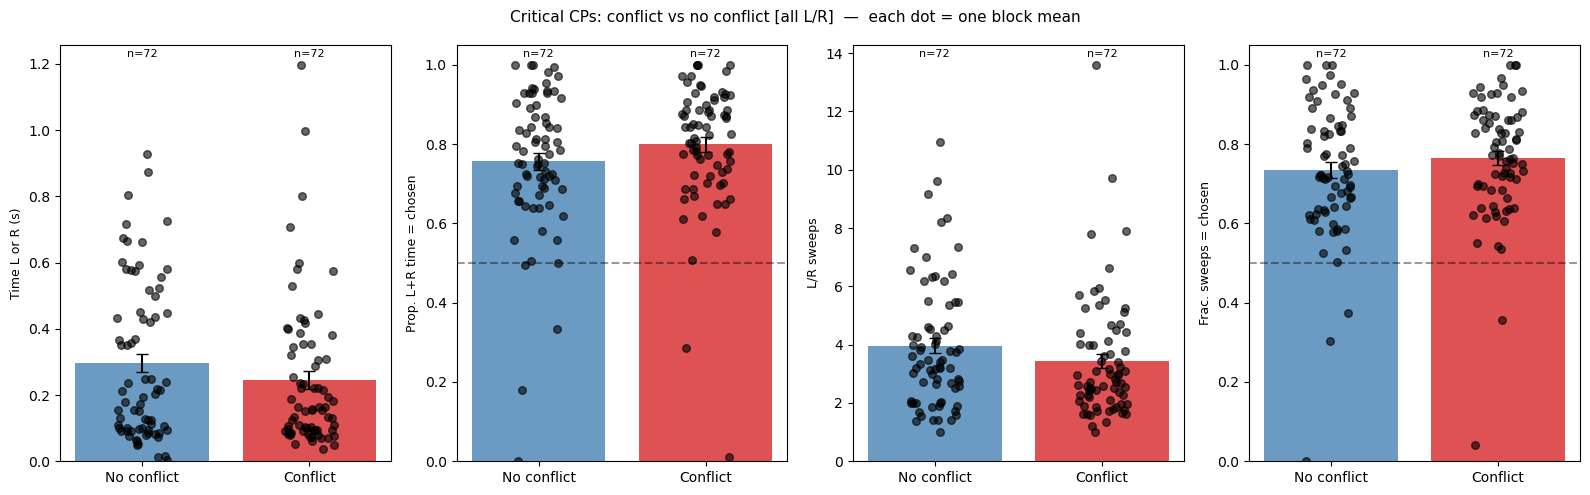

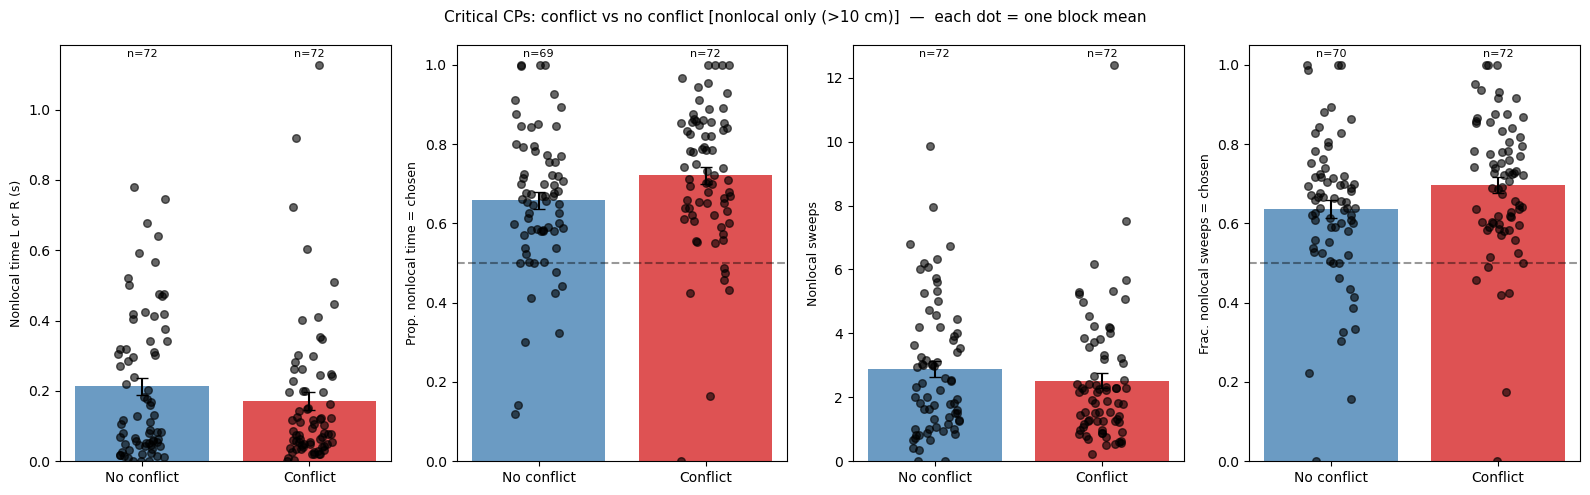

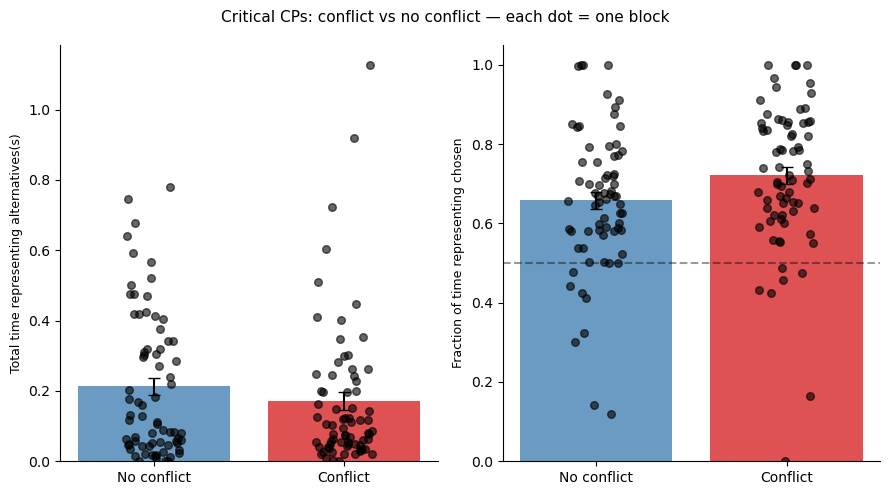

In [63]:
# ---- Conflict vs no-conflict: each dot = one block mean ----

all_metric_cols = ["time_lr_s", "nonlocal_time_lr_s", "prop_chosen", "prop_nonlocal_chosen",
                   "n_lr_sweeps", "n_nonlocal_sweeps", "frac_sweeps_chosen", "frac_nonlocal_sweeps_chosen"]
prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}

df_valid = stats_df.dropna(subset=["conflict"])
block_means_conf = (
    df_valid
    .groupby(["nwb_file_name", "epoch", "block", "conflict"])
    [all_metric_cols].mean().reset_index()
)

for metrics, label in [
    ([("time_lr_s", "Time L or R (s)"), ("prop_chosen", "Prop. L+R time = chosen"),
      ("n_lr_sweeps", "L/R sweeps"),    ("frac_sweeps_chosen", "Frac. sweeps = chosen")],
     "all L/R"),
    ([("nonlocal_time_lr_s", "Nonlocal time L or R (s)"), 
      ("prop_nonlocal_chosen", "Prop. nonlocal time = chosen"),
      ("n_nonlocal_sweeps",  "Nonlocal sweeps"),           
      ("frac_nonlocal_sweeps_chosen", "Frac. nonlocal sweeps = chosen")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        for x, (is_conflict, color) in enumerate([(False, "steelblue"), (True, "tab:red")]):
            vals = block_means_conf[block_means_conf["conflict"] == is_conflict][metric].dropna()
            ax.bar(x, vals.mean(), yerr=vals.sem(), color=color, capsize=4, alpha=0.8)
            ax.scatter(np.full(len(vals), x) + np.random.uniform(-0.15, 0.15, len(vals)),
                       vals, color="k", s=30, alpha=0.6, zorder=3)
        if metric in prop_metrics:
            ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["No conflict", "Conflict"])
        ax.set_ylabel(ylabel, fontsize=9)
        ymax = ax.get_ylim()[1]
        for x, is_conflict in enumerate([False, True]):
            n = block_means_conf[block_means_conf["conflict"] == is_conflict][metric].dropna().shape[0]
            ax.text(x, ymax * 0.97, f"n={n}", ha="center", fontsize=8)
    fig.suptitle(f"Critical CPs: conflict vs no conflict [{label}]  —  each dot = one block mean", fontsize=11)
    plt.tight_layout()
    plt.show()
    
    
fig, axes = plt.subplots(1, 2, figsize=(9, 5))

for ax, (metric, ylabel) in zip(axes, [
    ("nonlocal_time_lr_s",       "Total time representing alternatives(s)"),
    ("prop_nonlocal_chosen",     "Fraction of time representing chosen"),
]):
    for x, (is_conflict, color) in enumerate([(False, "steelblue"), (True, "tab:red")]):
        vals = block_means_conf[block_means_conf["conflict"] == is_conflict][metric].dropna()
        ax.bar(x, vals.mean(), yerr=vals.sem(), color=color, capsize=4, alpha=0.8, zorder=1)
        ax.scatter(np.full(len(vals), x) + np.random.uniform(-0.15, 0.15, len(vals)),
                   vals, color="k", s=30, alpha=0.6, zorder=3)

    if metric in prop_metrics:
        ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
        ax.set_ylim(0, 1.05)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No conflict", "Conflict"])
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Critical CPs: conflict vs no conflict — each dot = one block", fontsize=11)
plt.tight_layout()
plt.show()


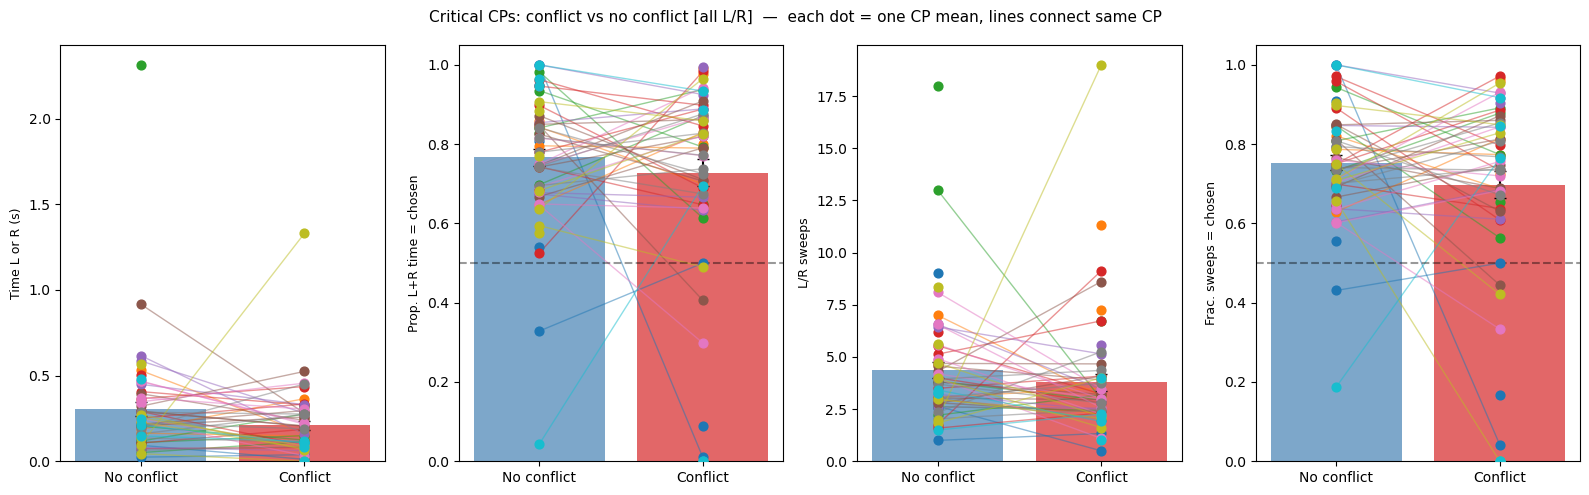

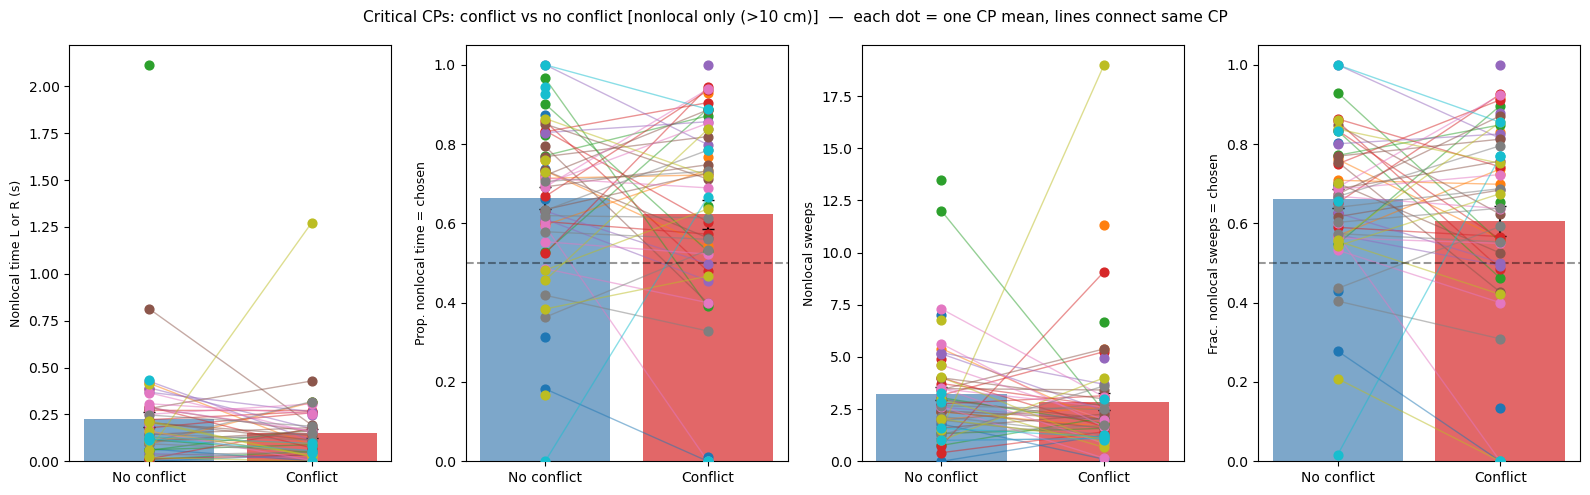

In [64]:
# ---- Conflict vs no-conflict: each dot = one (junction, entry_hex) mean ----
# Lines connect the same CP's no-conflict and conflict means.

all_metric_cols = ["time_lr_s", "nonlocal_time_lr_s", "prop_chosen", "prop_nonlocal_chosen",
                   "n_lr_sweeps", "n_nonlocal_sweeps", "frac_sweeps_chosen", "frac_nonlocal_sweeps_chosen"]
prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}

cp_means_conf = (
    df_valid
    .groupby(["junction", "entry_hex", "conflict"])
    [all_metric_cols].mean().reset_index()
)
cp_means_conf["label"] = cp_means_conf["junction"].astype(str) + "←" + cp_means_conf["entry_hex"].astype(str)
cp_labels = cp_means_conf["label"].unique()
cp_colors = dict(zip(cp_labels, plt.cm.tab10(np.linspace(0, 1, len(cp_labels)))))

for metrics, label in [
    ([("time_lr_s", "Time L or R (s)"), ("prop_chosen", "Prop. L+R time = chosen"),
      ("n_lr_sweeps", "L/R sweeps"),    ("frac_sweeps_chosen", "Frac. sweeps = chosen")],
     "all L/R"),
    ([("nonlocal_time_lr_s", "Nonlocal time L or R (s)"), 
      ("prop_nonlocal_chosen", "Prop. nonlocal time = chosen"),
      ("n_nonlocal_sweeps",  "Nonlocal sweeps"),           
      ("frac_nonlocal_sweeps_chosen", "Frac. nonlocal sweeps = chosen")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        for x, is_conflict in enumerate([False, True]):
            vals = cp_means_conf[cp_means_conf["conflict"] == is_conflict][metric].dropna()
            ax.bar(x, vals.mean(), yerr=vals.sem(), color=["steelblue", "tab:red"][x],
                   capsize=4, alpha=0.7, zorder=1)
        for lbl in cp_labels:
            color = cp_colors[lbl]
            pts = cp_means_conf[cp_means_conf["label"] == lbl].sort_values("conflict")
            xs = pts["conflict"].astype(int).values
            ys = pts[metric].values
            ax.plot(xs, ys, color=color, alpha=0.5, linewidth=1, zorder=2)
            ax.scatter(xs, ys, color=color, s=40, zorder=3, label=lbl)
        if metric in prop_metrics:
            ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["No conflict", "Conflict"])
        ax.set_ylabel(ylabel, fontsize=9)
    # axes[0].legend(title="junction←entry", bbox_to_anchor=(0, 1.02), loc="lower left",
    #                fontsize=7, title_fontsize=7, ncol=2)
    fig.suptitle(
        f"Critical CPs: conflict vs no conflict [{label}]  —  each dot = one CP mean, lines connect same CP",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

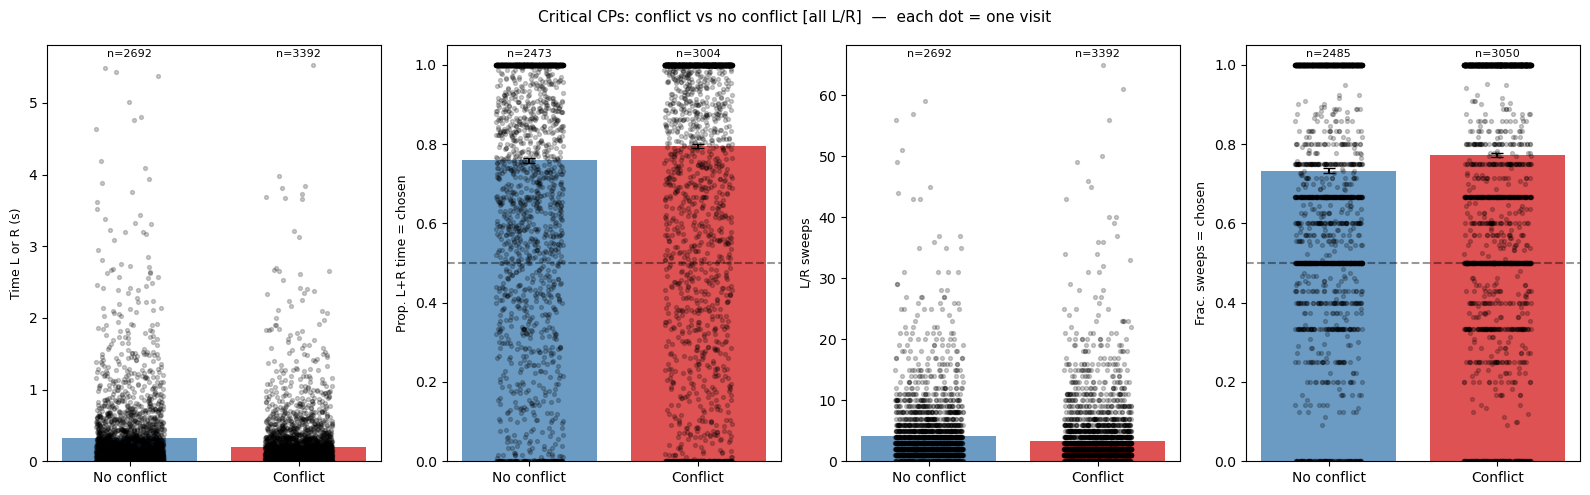

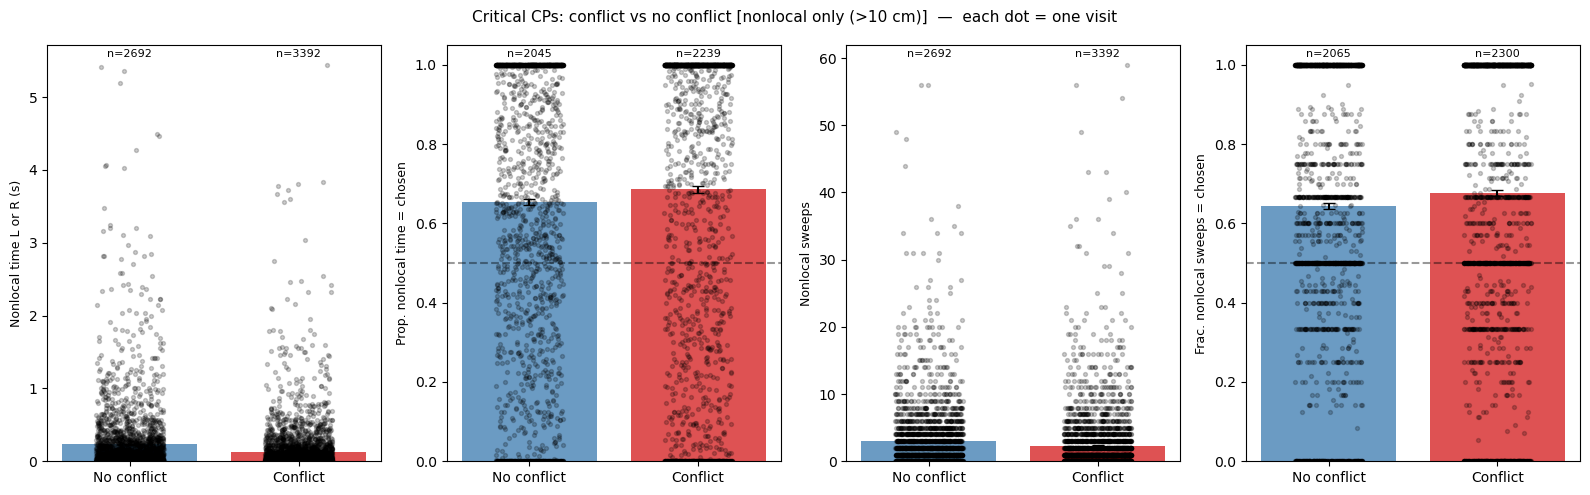

In [65]:
# ---- Conflict vs no-conflict: each dot = one individual CP visit ----

prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}

for metrics, label in [
    ([("time_lr_s", "Time L or R (s)"), ("prop_chosen", "Prop. L+R time = chosen"),
      ("n_lr_sweeps", "L/R sweeps"),    ("frac_sweeps_chosen", "Frac. sweeps = chosen")],
     "all L/R"),
    ([("nonlocal_time_lr_s", "Nonlocal time L or R (s)"), 
      ("prop_nonlocal_chosen", "Prop. nonlocal time = chosen"),
      ("n_nonlocal_sweeps",  "Nonlocal sweeps"),           
      ("frac_nonlocal_sweeps_chosen", "Frac. nonlocal sweeps = chosen")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        for x, (is_conflict, color) in enumerate([(False, "steelblue"), (True, "tab:red")]):
            vals = df_valid[df_valid["conflict"] == is_conflict][metric].dropna()
            ax.bar(x, vals.mean(), yerr=vals.sem(), color=color, capsize=4, alpha=0.8)
            ax.scatter(np.full(len(vals), x) + np.random.uniform(-0.2, 0.2, len(vals)),
                       vals, color="k", s=8, alpha=0.2, zorder=3)
        if metric in prop_metrics:
            ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["No conflict", "Conflict"])
        ax.set_ylabel(ylabel, fontsize=9)
        ymax = ax.get_ylim()[1]
        for x, is_conflict in enumerate([False, True]):
            n = df_valid[df_valid["conflict"] == is_conflict][metric].dropna().shape[0]
            ax.text(x, ymax * 0.97, f"n={n}", ha="center", fontsize=8)
    fig.suptitle(f"Critical CPs: conflict vs no conflict [{label}]  —  each dot = one visit", fontsize=11)
    plt.tight_layout()
    plt.show()

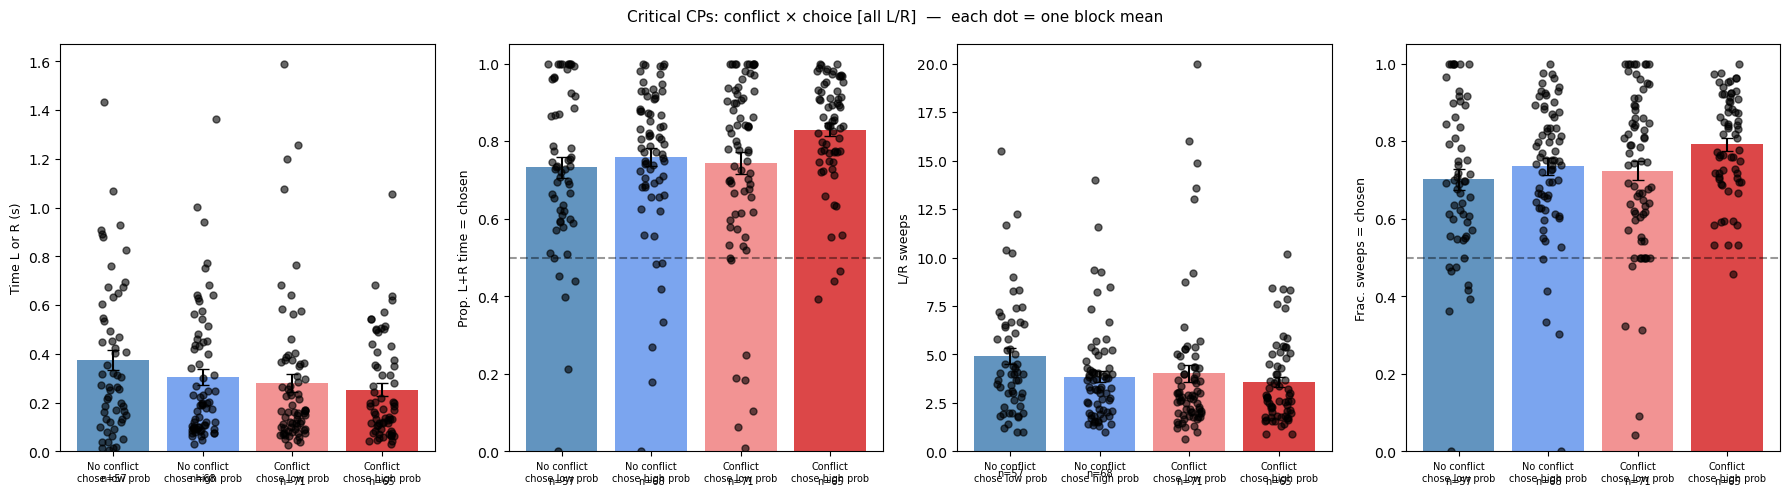

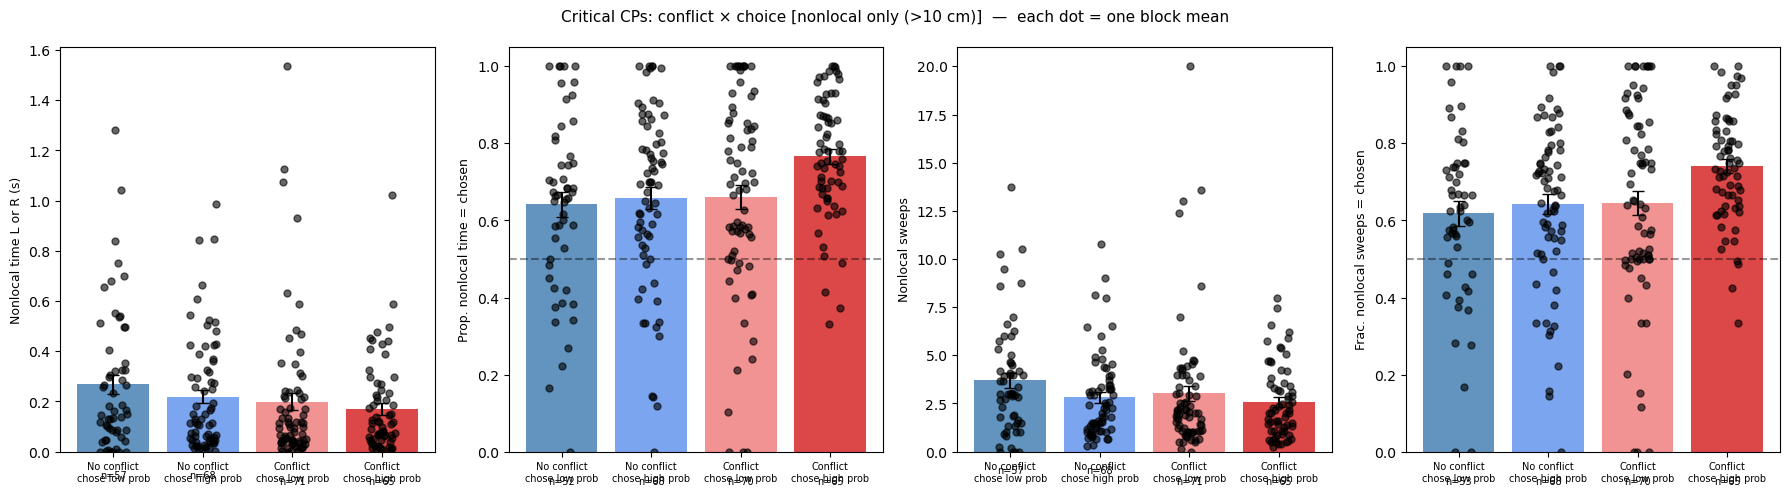

In [66]:
# ---- 2x2: conflict x chose_high_prob — each dot = one block mean ----

all_metric_cols = ["time_lr_s", "nonlocal_time_lr_s", "prop_chosen", "prop_nonlocal_chosen",
                   "n_lr_sweeps", "n_nonlocal_sweeps", "frac_sweeps_chosen", "frac_nonlocal_sweeps_chosen"]
prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}

categories = [
    (False, False, "No conflict\nchose low prob",  "steelblue"),
    (False, True,  "No conflict\nchose high prob", "cornflowerblue"),
    (True,  False, "Conflict\nchose low prob",     "lightcoral"),
    (True,  True,  "Conflict\nchose high prob",    "tab:red"),
]

block_means_2x2 = (
    df_valid
    .groupby(["nwb_file_name", "epoch", "block", "conflict", "chose_high_prob"])
    [all_metric_cols].mean().reset_index()
)

for metrics, label in [
    ([("time_lr_s", "Time L or R (s)"), ("prop_chosen", "Prop. L+R time = chosen"),
      ("n_lr_sweeps", "L/R sweeps"),    ("frac_sweeps_chosen", "Frac. sweeps = chosen")],
     "all L/R"),
    ([("nonlocal_time_lr_s", "Nonlocal time L or R (s)"), 
      ("prop_nonlocal_chosen", "Prop. nonlocal time = chosen"),
      ("n_nonlocal_sweeps",  "Nonlocal sweeps"),           
      ("frac_nonlocal_sweeps_chosen", "Frac. nonlocal sweeps = chosen")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        for x, (is_conflict, chose_high, cat_label, color) in enumerate(categories):
            vals = block_means_2x2[
                (block_means_2x2["conflict"] == is_conflict) &
                (block_means_2x2["chose_high_prob"] == chose_high)
            ][metric].dropna()
            if len(vals) == 0:
                continue
            ax.bar(x, vals.mean(), yerr=vals.sem(), color=color, capsize=4, alpha=0.85)
            ax.scatter(np.full(len(vals), x) + np.random.uniform(-0.15, 0.15, len(vals)),
                       vals, color="k", s=25, alpha=0.6, zorder=3)
            ax.text(x, -ax.get_ylim()[1] * 0.08, f"n={len(vals)}", ha="center", fontsize=7, clip_on=False)
        if metric in prop_metrics:
            ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks(range(len(categories)))
        ax.set_xticklabels([c[2] for c in categories], fontsize=7)
        ax.set_ylabel(ylabel, fontsize=9)
    fig.suptitle(f"Critical CPs: conflict × choice [{label}]  —  each dot = one block mean", fontsize=11)
    plt.tight_layout()
    plt.show()

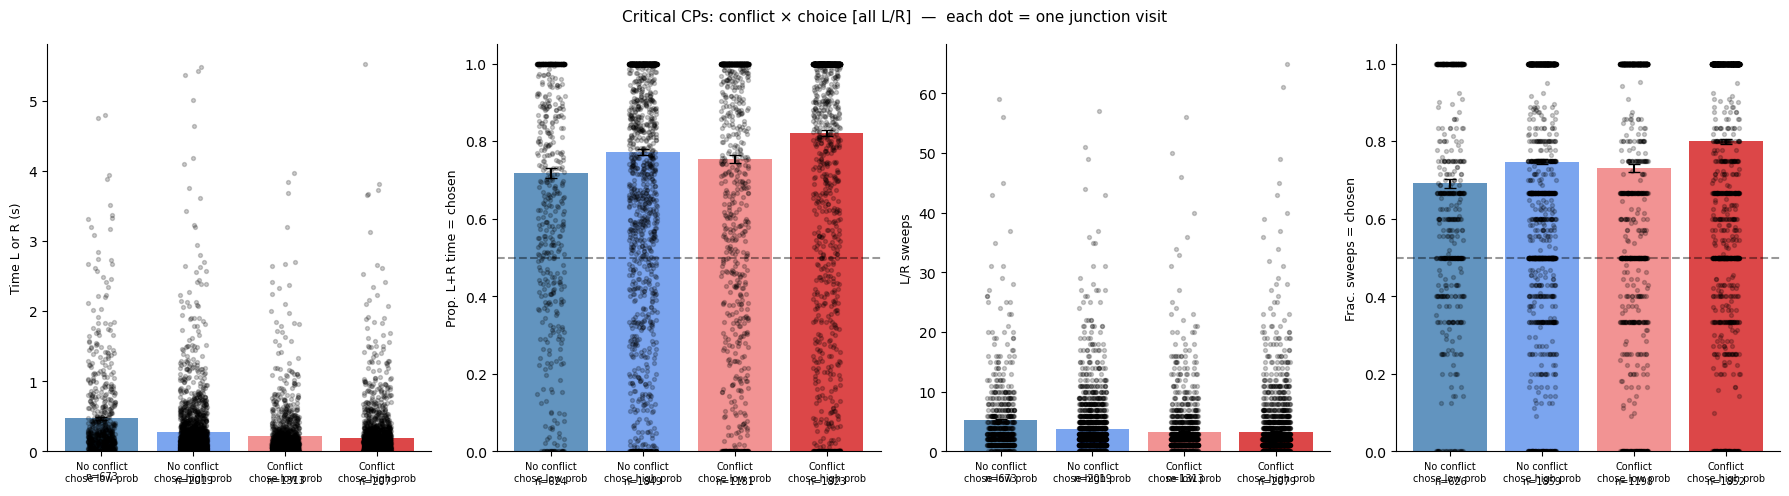

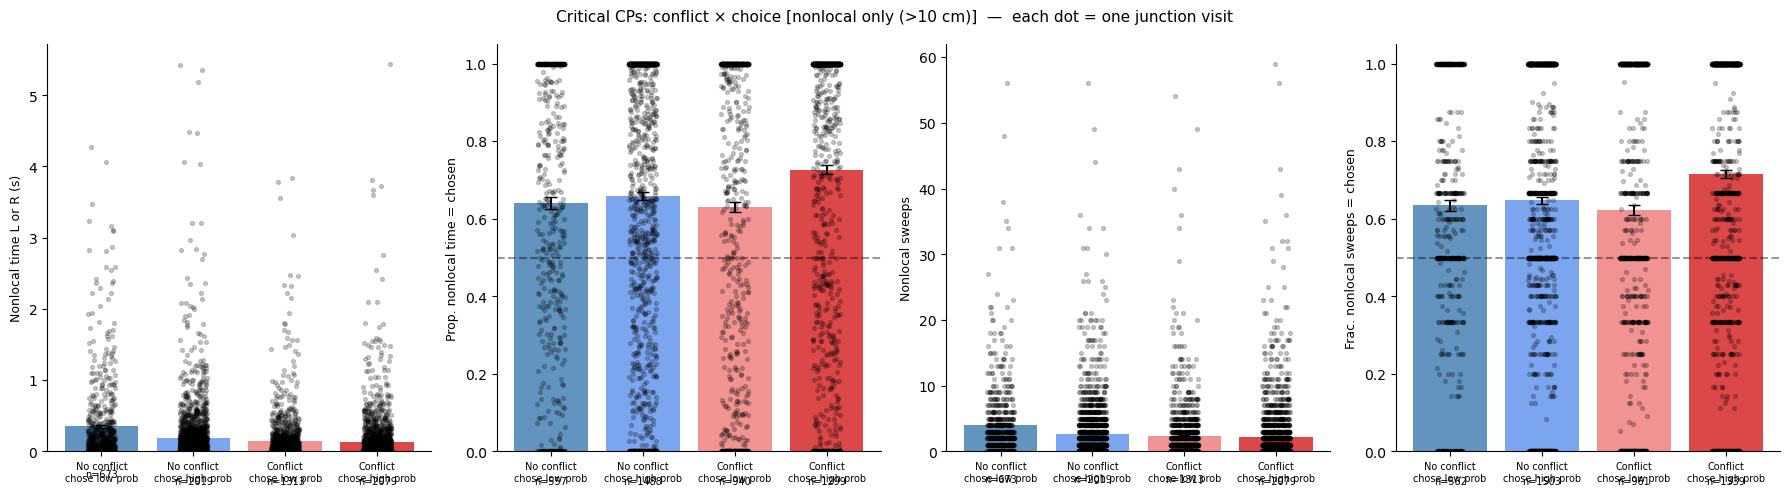

In [67]:
# ---- 2x2: conflict x chose_high_prob — each dot = one junction visit ----

all_metric_cols = ["time_lr_s", "nonlocal_time_lr_s", "prop_chosen", "prop_nonlocal_chosen",
                   "n_lr_sweeps", "n_nonlocal_sweeps", "frac_sweeps_chosen", "frac_nonlocal_sweeps_chosen"]
prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}

categories = [
    (False, False, "No conflict\nchose low prob",  "steelblue"),
    (False, True,  "No conflict\nchose high prob", "cornflowerblue"),
    (True,  False, "Conflict\nchose low prob",     "lightcoral"),
    (True,  True,  "Conflict\nchose high prob",    "tab:red"),
]

for metrics, label in [
    ([("time_lr_s", "Time L or R (s)"), ("prop_chosen", "Prop. L+R time = chosen"),
      ("n_lr_sweeps", "L/R sweeps"),    ("frac_sweeps_chosen", "Frac. sweeps = chosen")],
     "all L/R"),
    ([("nonlocal_time_lr_s", "Nonlocal time L or R (s)"),
      ("prop_nonlocal_chosen", "Prop. nonlocal time = chosen"),
      ("n_nonlocal_sweeps",  "Nonlocal sweeps"),
      ("frac_nonlocal_sweeps_chosen", "Frac. nonlocal sweeps = chosen")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        for x, (is_conflict, chose_high, cat_label, color) in enumerate(categories):
            vals = df_valid[
                (df_valid["conflict"] == is_conflict) &
                (df_valid["chose_high_prob"] == chose_high)
            ][metric].dropna()
            if len(vals) == 0:
                continue
            ax.bar(x, vals.mean(), yerr=vals.sem(), color=color, capsize=4, alpha=0.85, zorder=1)
            ax.scatter(np.full(len(vals), x) + np.random.uniform(-0.15, 0.15, len(vals)),
                       vals, color="k", s=8, alpha=0.2, zorder=3)
            ax.text(x, -ax.get_ylim()[1] * 0.08, f"n={len(vals)}", ha="center", fontsize=7, clip_on=False)

        if metric in prop_metrics:
            ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks(range(len(categories)))
        ax.set_xticklabels([c[2] for c in categories], fontsize=7)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(f"Critical CPs: conflict × choice [{label}]  —  each dot = one junction visit", fontsize=11)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_1233822/2888886391.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["chose_short_path"] = df_valid["path_length_diff"] < 0


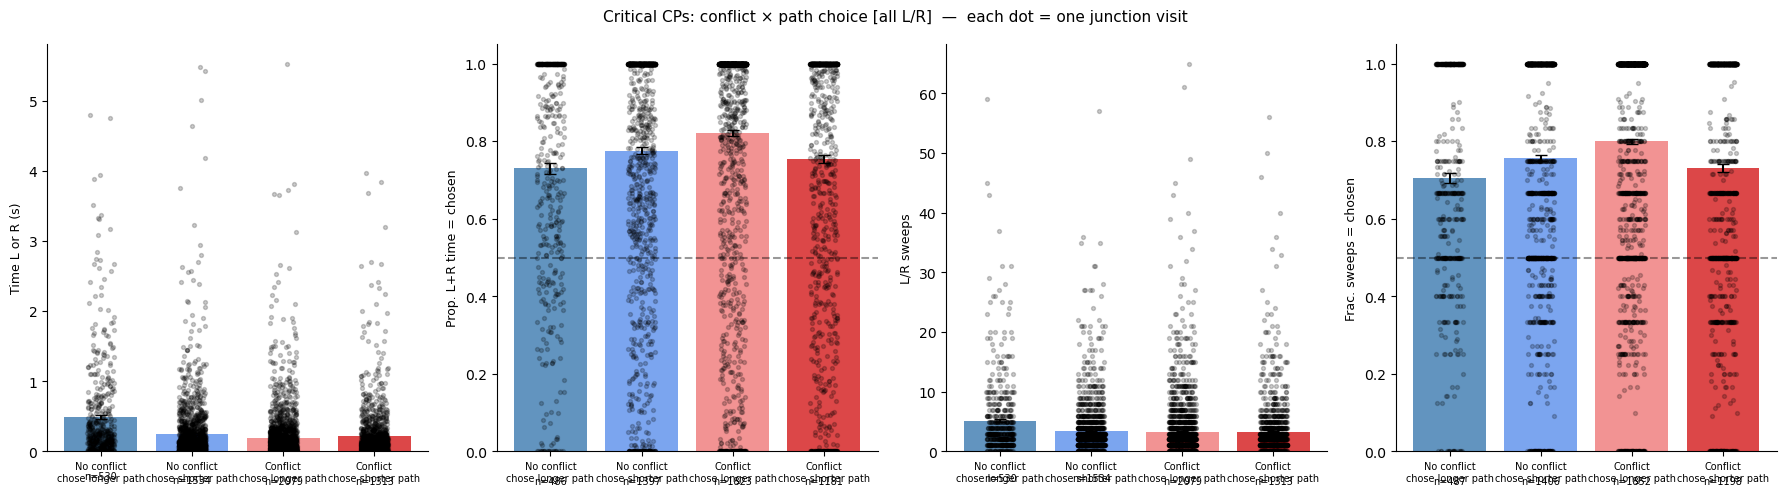

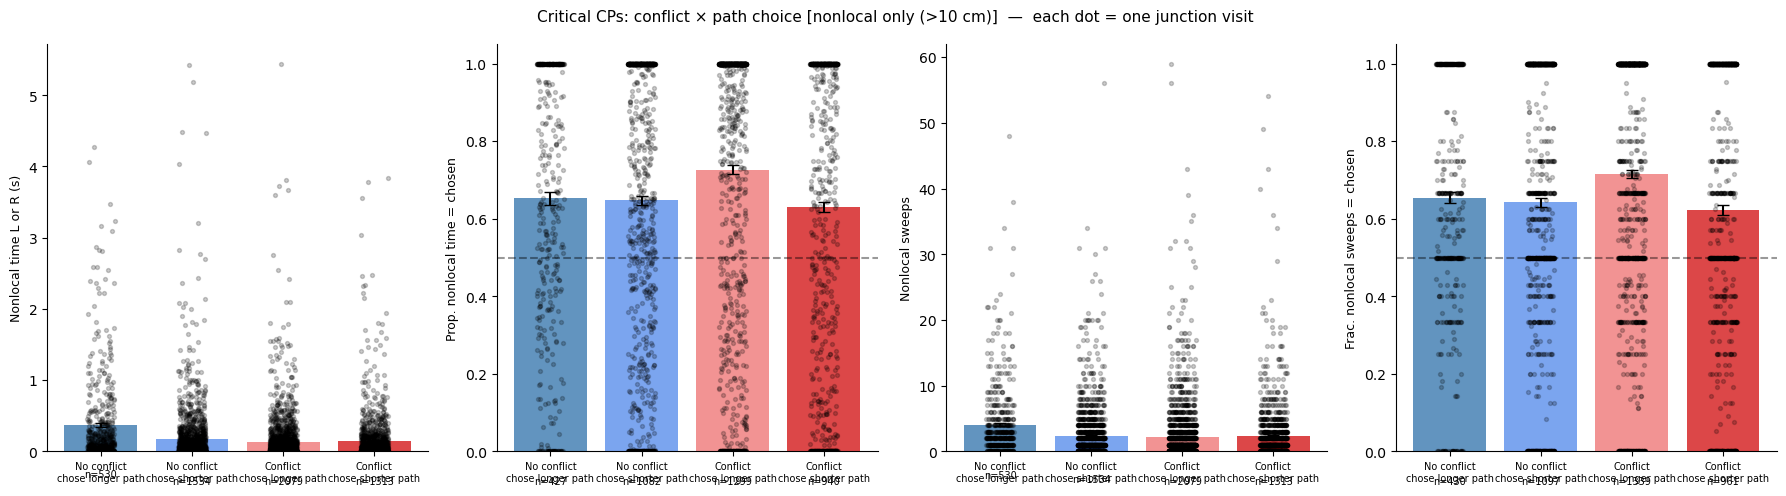

In [68]:
# ---- 2x2: conflict x chose_short_path — each dot = one junction visit ----

df_valid["chose_short_path"] = df_valid["path_length_diff"] < 0
df_path = df_valid[df_valid["path_length_diff"] != 0]


all_metric_cols = ["time_lr_s", "nonlocal_time_lr_s", "prop_chosen", "prop_nonlocal_chosen",
                   "n_lr_sweeps", "n_nonlocal_sweeps", "frac_sweeps_chosen", "frac_nonlocal_sweeps_chosen"]
prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}

categories = [
    (False, False, "No conflict\nchose longer path",  "steelblue"),
    (False, True,  "No conflict\nchose shorter path", "cornflowerblue"),
    (True,  False, "Conflict\nchose longer path",     "lightcoral"),
    (True,  True,  "Conflict\nchose shorter path",    "tab:red"),
]

for metrics, label in [
    ([("time_lr_s", "Time L or R (s)"), ("prop_chosen", "Prop. L+R time = chosen"),
      ("n_lr_sweeps", "L/R sweeps"),    ("frac_sweeps_chosen", "Frac. sweeps = chosen")],
     "all L/R"),
    ([("nonlocal_time_lr_s", "Nonlocal time L or R (s)"),
      ("prop_nonlocal_chosen", "Prop. nonlocal time = chosen"),
      ("n_nonlocal_sweeps",  "Nonlocal sweeps"),
      ("frac_nonlocal_sweeps_chosen", "Frac. nonlocal sweeps = chosen")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        for x, (is_conflict, chose_short, cat_label, color) in enumerate(categories):
            vals = df_path[
                (df_path["conflict"] == is_conflict) &
                (df_path["chose_short_path"] == chose_short)
            ][metric].dropna()
            if len(vals) == 0:
                continue
            ax.bar(x, vals.mean(), yerr=vals.sem(), color=color, capsize=4, alpha=0.85, zorder=1)
            ax.scatter(np.full(len(vals), x) + np.random.uniform(-0.15, 0.15, len(vals)),
                       vals, color="k", s=8, alpha=0.2, zorder=3)
            ax.text(x, -ax.get_ylim()[1] * 0.08, f"n={len(vals)}", ha="center", fontsize=7, clip_on=False)

        if metric in prop_metrics:
            ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks(range(len(categories)))
        ax.set_xticklabels([c[2] for c in categories], fontsize=7)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(f"Critical CPs: conflict × path choice [{label}]  —  each dot = one junction visit", fontsize=11)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_1233822/1306109672.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["chose_short_path"] = df_valid["path_length_diff"] < 0


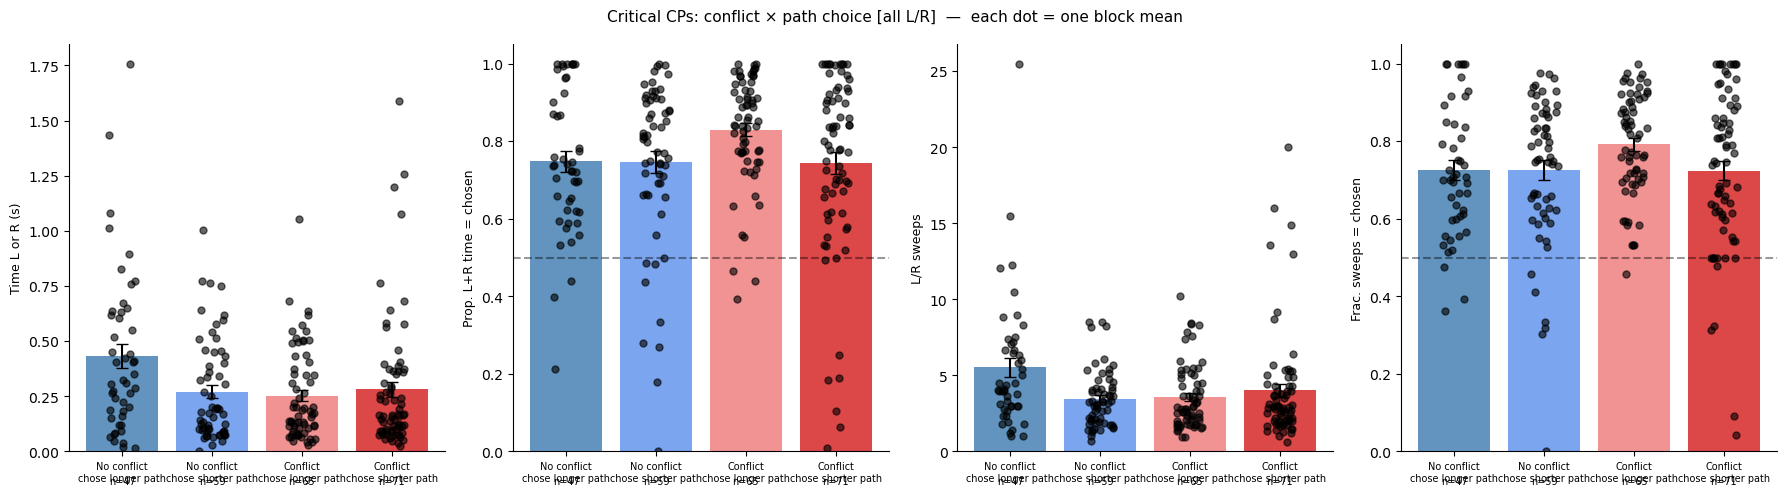

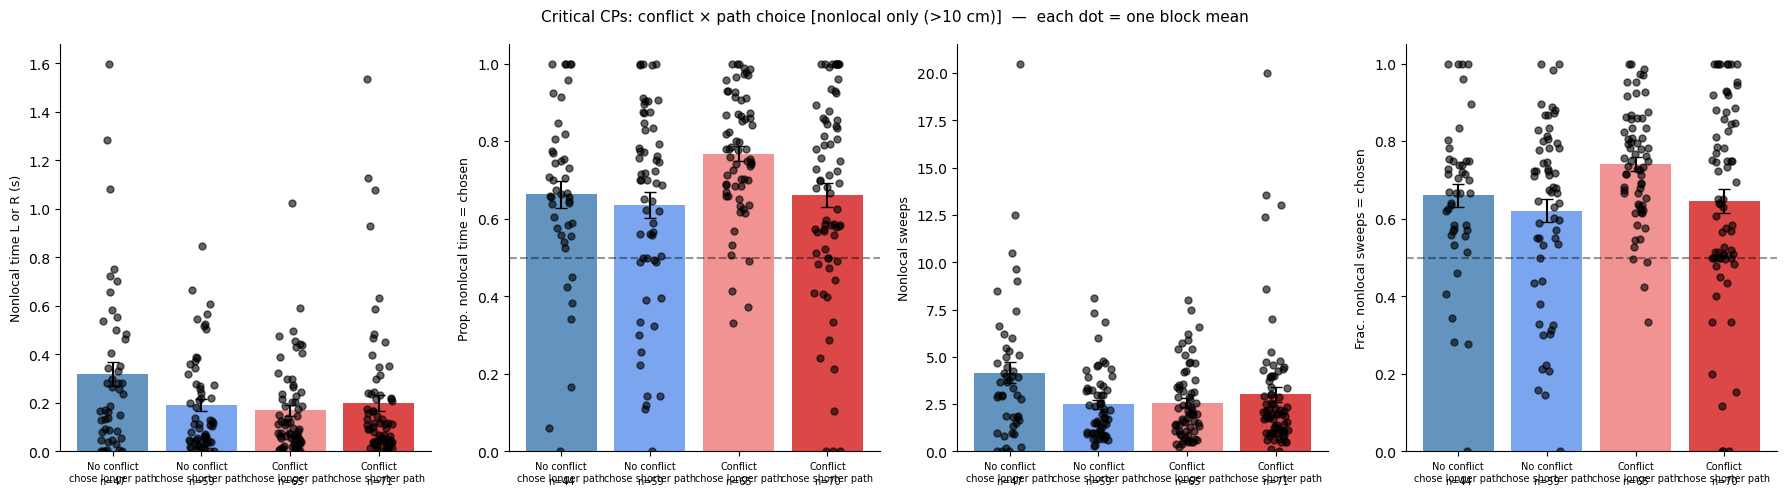

In [69]:
# ---- 2x2: conflict x chose_short_path — each dot = one block mean ----

df_valid["chose_short_path"] = df_valid["path_length_diff"] < 0
df_path = df_valid[df_valid["path_length_diff"] != 0]



all_metric_cols = ["time_lr_s", "nonlocal_time_lr_s", "prop_chosen", "prop_nonlocal_chosen",
                   "n_lr_sweeps", "n_nonlocal_sweeps", "frac_sweeps_chosen", "frac_nonlocal_sweeps_chosen"]
prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}

categories = [
    (False, False, "No conflict\nchose longer path",  "steelblue"),
    (False, True,  "No conflict\nchose shorter path", "cornflowerblue"),
    (True,  False, "Conflict\nchose longer path",     "lightcoral"),
    (True,  True,  "Conflict\nchose shorter path",    "tab:red"),
]

block_means_2x2 = (
    df_path
    .groupby(["nwb_file_name", "epoch", "block", "conflict", "chose_short_path"])
    [all_metric_cols].mean().reset_index()
)

for metrics, label in [
    ([("time_lr_s", "Time L or R (s)"), ("prop_chosen", "Prop. L+R time = chosen"),
      ("n_lr_sweeps", "L/R sweeps"),    ("frac_sweeps_chosen", "Frac. sweeps = chosen")],
     "all L/R"),
    ([("nonlocal_time_lr_s", "Nonlocal time L or R (s)"),
      ("prop_nonlocal_chosen", "Prop. nonlocal time = chosen"),
      ("n_nonlocal_sweeps",  "Nonlocal sweeps"),
      ("frac_nonlocal_sweeps_chosen", "Frac. nonlocal sweeps = chosen")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        for x, (is_conflict, chose_short, cat_label, color) in enumerate(categories):
            vals = block_means_2x2[
                (block_means_2x2["conflict"] == is_conflict) &
                (block_means_2x2["chose_short_path"] == chose_short)
            ][metric].dropna()
            if len(vals) == 0:
                continue
            ax.bar(x, vals.mean(), yerr=vals.sem(), color=color, capsize=4, alpha=0.85, zorder=1)
            ax.scatter(np.full(len(vals), x) + np.random.uniform(-0.15, 0.15, len(vals)),
                       vals, color="k", s=25, alpha=0.6, zorder=3)
            ax.text(x, -ax.get_ylim()[1] * 0.08, f"n={len(vals)}", ha="center", fontsize=7, clip_on=False)

        if metric in prop_metrics:
            ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
            ax.set_ylim(0, 1.05)
        ax.set_xticks(range(len(categories)))
        ax.set_xticklabels([c[2] for c in categories], fontsize=7)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(f"Critical CPs: conflict × path choice [{label}]  —  each dot = one block mean", fontsize=11)
    plt.tight_layout()
    plt.show()


## Single animal aggregation

All the same analyses as above, but collapsed to one dot per animal.
Animal ID is extracted from the nwb filename (e.g. `IM-1478_20220719_.nwb` → `IM-1478`).

Runs three comparisons:
1. **Critical vs other junctions** — does this animal sweep more / more toward chosen at critical CPs?
2. **First vs last trials** — does this animal show more sweeping with experience?
3. **Conflict vs no-conflict** — does this animal sweep more when the choice is harder?

Requires Cell 3 (`all_stats_df`, `stats_df`) to be populated.
First/last trials requires Cell 5 (`block_half_means`, `HALF_SIZE`).
Conflict requires Cell 12 (`conflict` column in `stats_df`).

Animals (4): ['IM-1478', 'IM-1594', 'IM-1947', 'Toby']


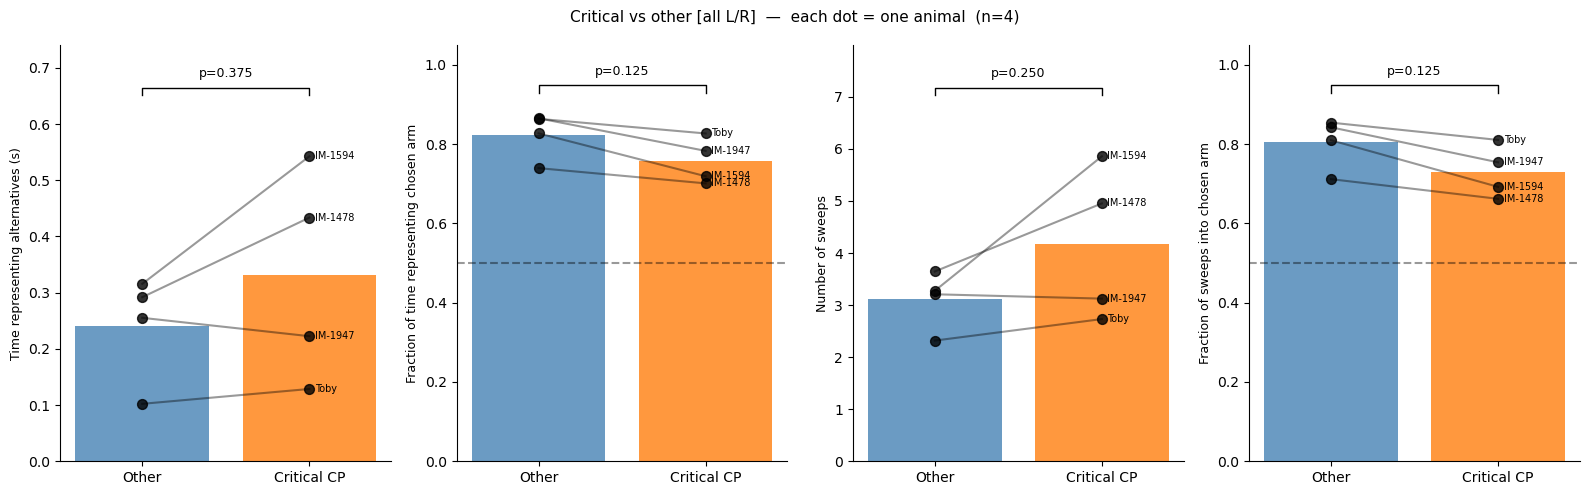

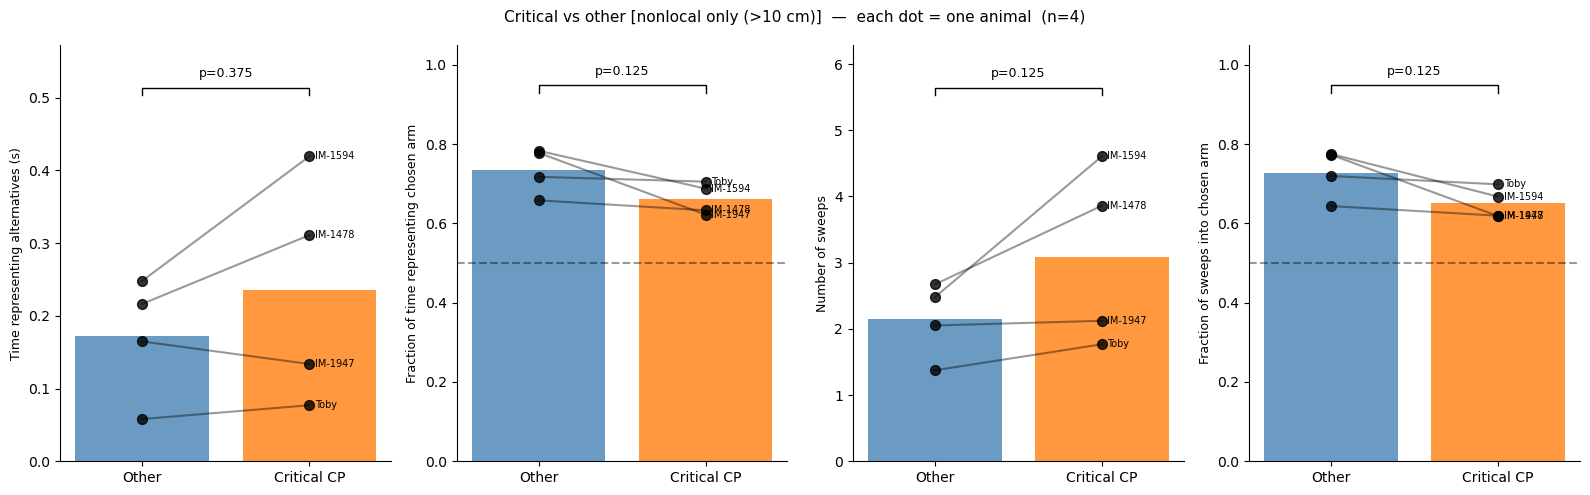

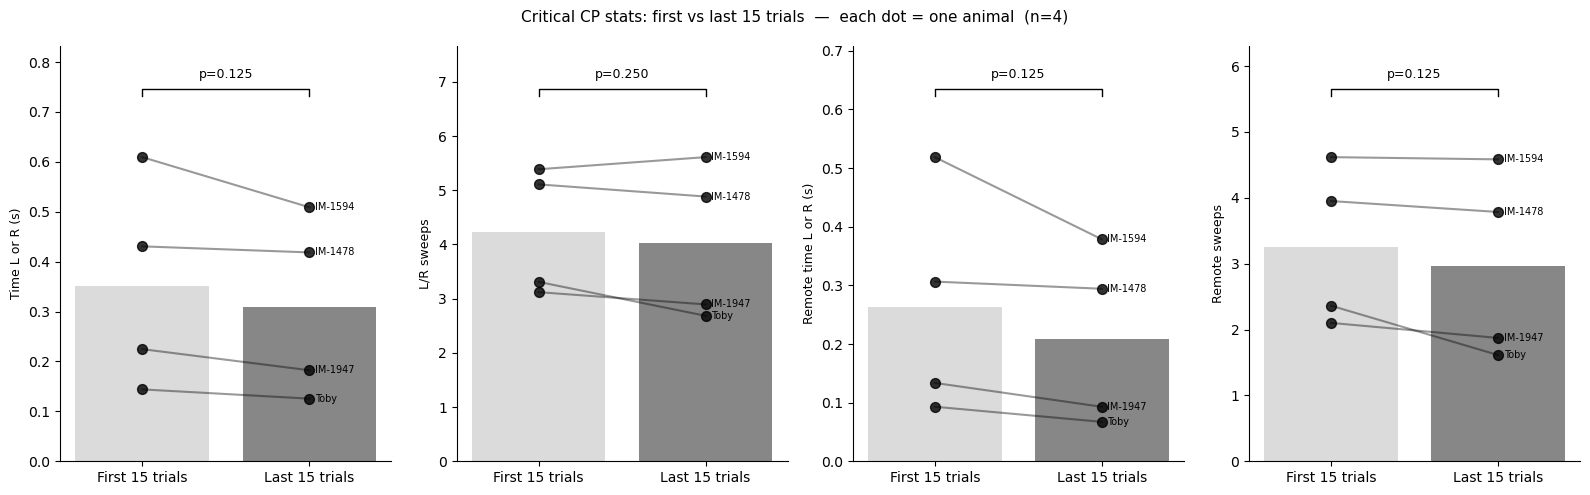

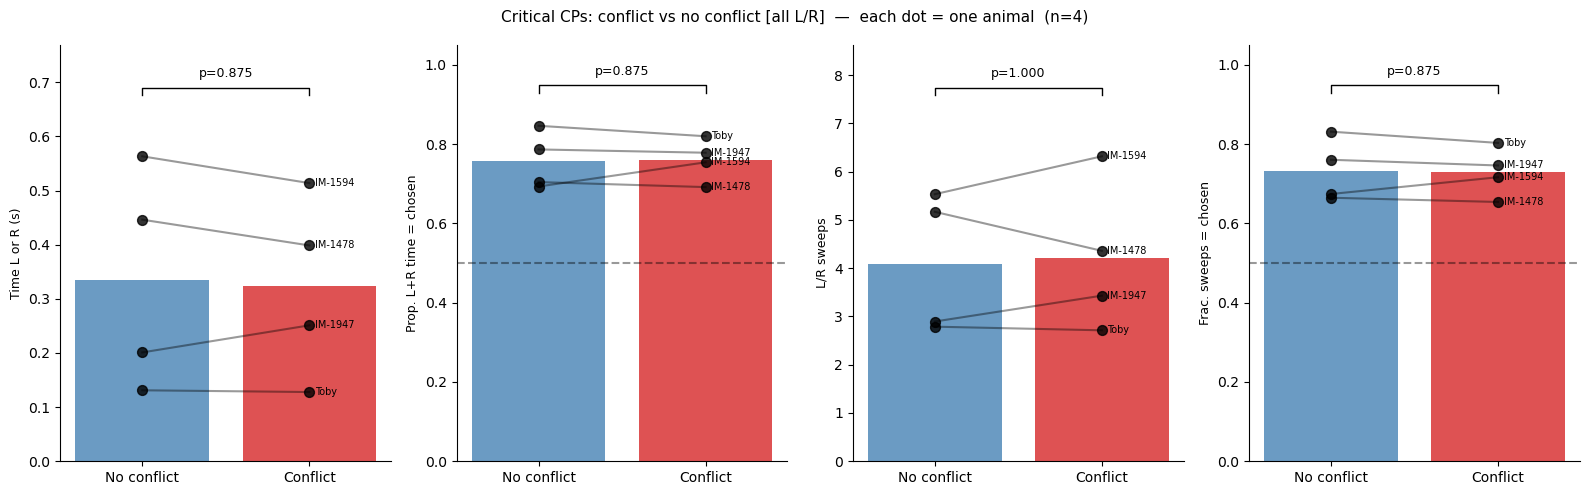

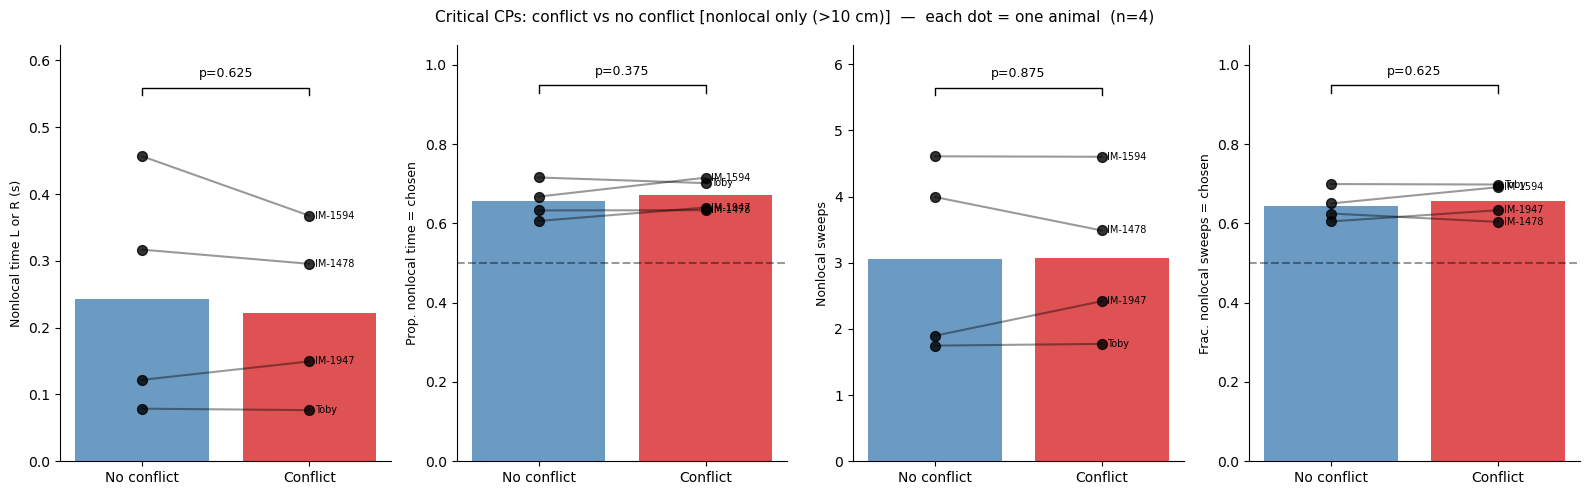

In [70]:
import re
from scipy import stats

# Extract animal ID from nwb_file_name.
# Handles both formats:
#   IM-1478_20220719_.nwb  →  IM-1478   (underscore before 8-digit date)
#   Toby20250316_.nwb      →  Toby      (date runs directly after animal name)
def _extract_animal(nwb_name):
    m = re.match(r"^([A-Za-z0-9\-]+?)(?:_?\d{8})", nwb_name)
    return m.group(1) if m else nwb_name

# Helper: draw one paired bar+scatter plot with Wilcoxon annotation.
# animal_vals is a DataFrame with one row per animal, columns col_a and col_b.
def _plot_paired_animals(ax, animal_vals, col_a, col_b, color_a, color_b, metric, prop_metrics):
    # Mean bars
    ax.bar(0, animal_vals[col_a].mean(), color=color_a, alpha=0.8, zorder=1)
    ax.bar(1, animal_vals[col_b].mean(), color=color_b, alpha=0.8, zorder=1)

    # One dot + line per animal, with animal name label
    for anim, row in animal_vals.iterrows():
        ax.plot([0, 1], [row[col_a], row[col_b]], color="k", alpha=0.4, linewidth=1.5, zorder=2)
        ax.scatter([0, 1], [row[col_a], row[col_b]], color="k", s=50, alpha=0.8, zorder=3)
        ax.annotate(str(anim), (1, row[col_b]), fontsize=7, va="center", ha="left",
                    xytext=(4, 0), textcoords="offset points")

    # Wilcoxon signed-rank test (falls back to showing n if too few animals)
    try:
        _, p = stats.wilcoxon(animal_vals[col_a], animal_vals[col_b])
        p_str = f"p={p:.3f}"
    except Exception:
        p_str = f"n={len(animal_vals)}"

    # Significance bracket — placed inside ylim for proportion metrics, above bars otherwise
    if metric in prop_metrics:
        ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
        ax.set_ylim(0, 1.05)
        bracket_y = 0.93
    else:
        ax.set_ylim(top=ax.get_ylim()[1] * 1.3)
        bracket_y = ax.get_ylim()[1] * 0.88

    ax.plot([0, 0, 1, 1], [bracket_y, bracket_y * 1.02, bracket_y * 1.02, bracket_y], color="k", linewidth=1)
    ax.text(0.5, bracket_y * 1.04, p_str, ha="center", va="bottom", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Add animal column to the main dataframes
all_stats_df["animal"] = all_stats_df["nwb_file_name"].apply(_extract_animal)
stats_df["animal"]     = stats_df["nwb_file_name"].apply(_extract_animal)

n_animals  = all_stats_df["animal"].nunique()
animal_list = sorted(all_stats_df["animal"].unique())
print(f"Animals ({n_animals}): {animal_list}")

all_metric_cols = [
    "time_lr_s", "nonlocal_time_lr_s",
    "prop_chosen", "prop_nonlocal_chosen",
    "n_lr_sweeps", "n_nonlocal_sweeps",
    "frac_sweeps_chosen", "frac_nonlocal_sweeps_chosen",
]
prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}


# ── 1. Critical vs other junctions ─────────────────────────────────────────────
# Average all visits within each (animal, is_critical) combination, then pair up.
animal_means_crit = (
    all_stats_df
    .groupby(["animal", "is_critical"])
    [all_metric_cols].mean()
)

for metrics, label in [
    ([("time_lr_s",          "Time representing alternatives (s)"),
      ("prop_chosen",        "Fraction of time representing chosen arm"),
      ("n_lr_sweeps",        "Number of sweeps"),
      ("frac_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "all L/R"),
    ([("nonlocal_time_lr_s",          "Time representing alternatives (s)"),
      ("prop_nonlocal_chosen",         "Fraction of time representing chosen arm"),
      ("n_nonlocal_sweeps",           "Number of sweeps"),
      ("frac_nonlocal_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        # pivot to get one row per animal with columns False (other) and True (critical)
        paired = animal_means_crit[metric].unstack("is_critical").dropna()
        _plot_paired_animals(ax, paired, False, True, "steelblue", "tab:orange", metric, prop_metrics)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Other", "Critical CP"])
        ax.set_ylabel(ylabel, fontsize=9)
    fig.suptitle(
        f"Critical vs other [{label}]  —  each dot = one animal  (n={n_animals})",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()


# ── 2. First vs last trials ─────────────────────────────────────────────────────
# Requires block_half_means and HALF_SIZE from Cell 5.
if "block_half_means" in globals() and "HALF_SIZE" in globals():
    block_half_means["animal"] = block_half_means["nwb_file_name"].apply(_extract_animal)

    first_label = f"First {HALF_SIZE} trials"
    last_label  = f"Last {HALF_SIZE} trials"
    half_metrics_local = ["time_lr_s", "nonlocal_time_lr_s", "n_lr_sweeps", "n_nonlocal_sweeps"]
    half_metric_labels_local = [
        ("time_lr_s",          "Time L or R (s)"),
        ("n_lr_sweeps",        "L/R sweeps"),
        ("nonlocal_time_lr_s", "Remote time L or R (s)"),
        ("n_nonlocal_sweeps",  "Remote sweeps"),
    ]

    # Average blocks within each (animal, block_half) then pivot
    animal_half_means = (
        block_half_means.dropna(subset=["block_half"])
        .groupby(["animal", "block_half"])
        [half_metrics_local].mean()
    )

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (metric, ylabel) in zip(axes, half_metric_labels_local):
        paired = animal_half_means[metric].unstack("block_half")
        if first_label in paired.columns and last_label in paired.columns:
            paired = paired[[first_label, last_label]].dropna()
            _plot_paired_animals(ax, paired, first_label, last_label, "lightgray", "dimgray", metric, prop_metrics)
        ax.set_xticks([0, 1])
        ax.set_xticklabels([first_label, last_label])
        ax.set_ylabel(ylabel, fontsize=9)
    fig.suptitle(
        f"Critical CP stats: first vs last {HALF_SIZE} trials  —  each dot = one animal  (n={n_animals})",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()
else:
    print("Skipping first/last plot — run Cell 5 first to populate block_half_means.")


# ── 3. Conflict vs no-conflict ──────────────────────────────────────────────────
# Requires stats_df to have conflict column (from Cell 12).
if "conflict" in stats_df.columns:
    df_valid_anim = stats_df.dropna(subset=["conflict"]).copy()
    df_valid_anim["animal"] = df_valid_anim["nwb_file_name"].apply(_extract_animal)

    # Average critical CP visits within each (animal, conflict) combination
    animal_means_conf = (
        df_valid_anim
        .groupby(["animal", "conflict"])
        [all_metric_cols].mean()
    )

    for metrics, label in [
        ([("time_lr_s",          "Time L or R (s)"),
          ("prop_chosen",        "Prop. L+R time = chosen"),
          ("n_lr_sweeps",        "L/R sweeps"),
          ("frac_sweeps_chosen", "Frac. sweeps = chosen")],
         "all L/R"),
        ([("nonlocal_time_lr_s",          "Nonlocal time L or R (s)"),
          ("prop_nonlocal_chosen",         "Prop. nonlocal time = chosen"),
          ("n_nonlocal_sweeps",           "Nonlocal sweeps"),
          ("frac_nonlocal_sweeps_chosen", "Frac. nonlocal sweeps = chosen")],
         "nonlocal only (>10 cm)"),
    ]:
        fig, axes = plt.subplots(1, 4, figsize=(16, 5))
        for ax, (metric, ylabel) in zip(axes, metrics):
            paired = animal_means_conf[metric].unstack("conflict").dropna()
            _plot_paired_animals(ax, paired, False, True, "steelblue", "tab:red", metric, prop_metrics)
            ax.set_xticks([0, 1])
            ax.set_xticklabels(["No conflict", "Conflict"])
            ax.set_ylabel(ylabel, fontsize=9)
        fig.suptitle(
            f"Critical CPs: conflict vs no conflict [{label}]  —  each dot = one animal  (n={n_animals})",
            fontsize=11
        )
        plt.tight_layout()
        plt.show()
else:
    print("Skipping conflict plot — run Cell 12 first to add conflict column to stats_df.")

Animals (4): ['IM-1478', 'IM-1594', 'IM-1947', 'Toby']


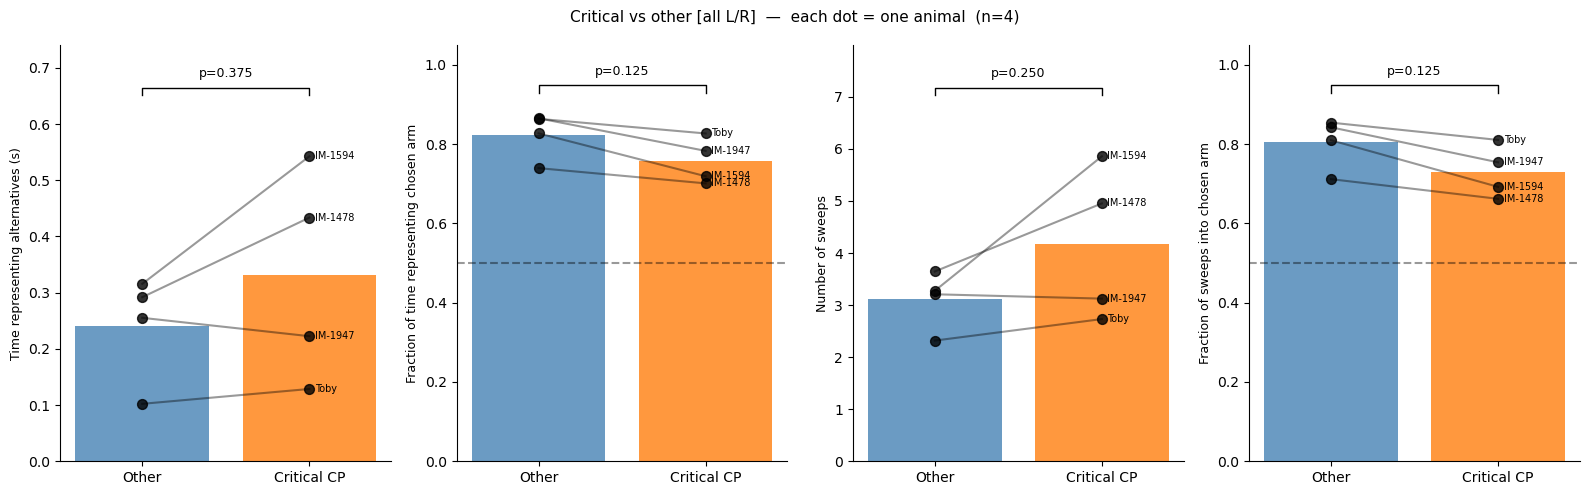

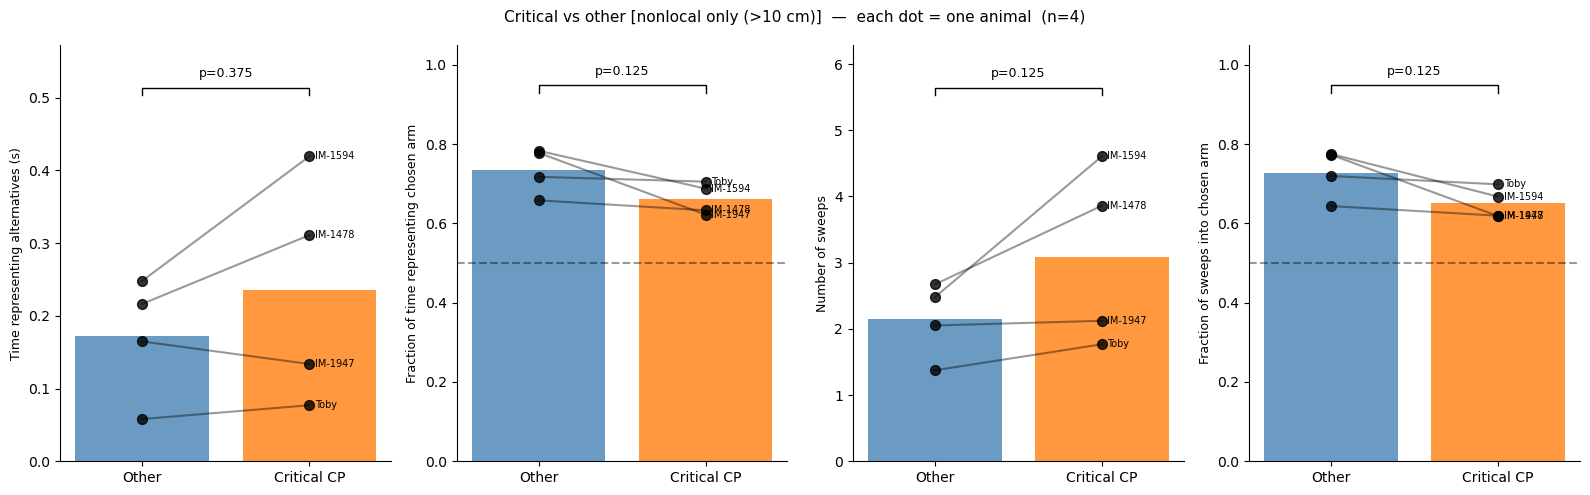

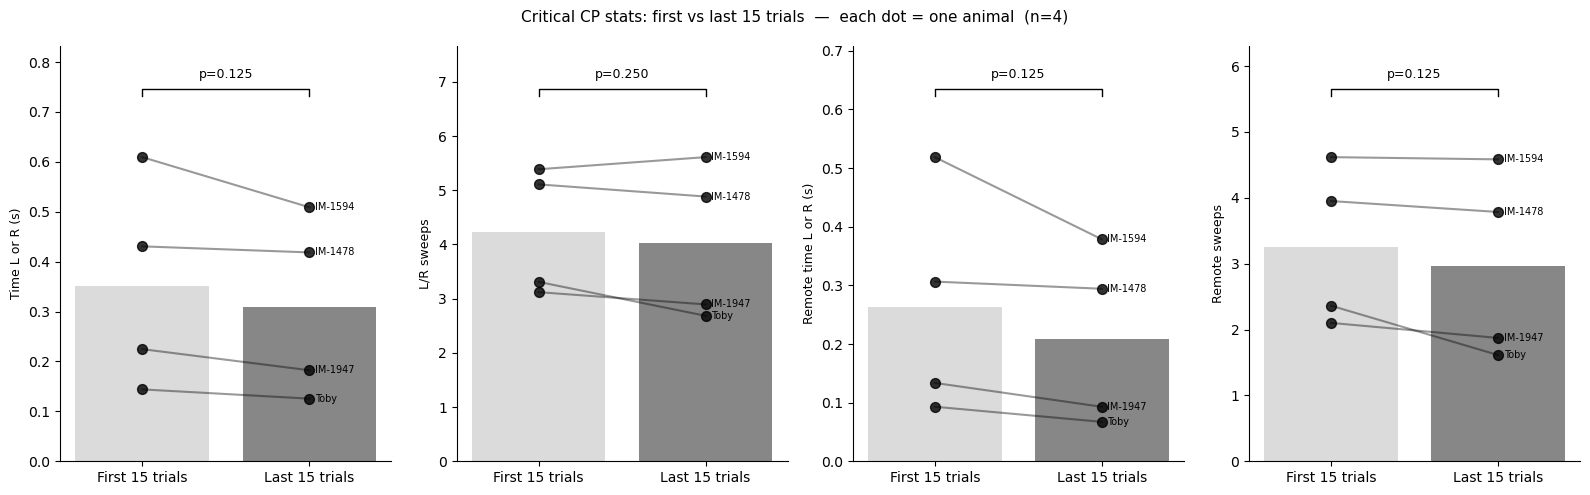

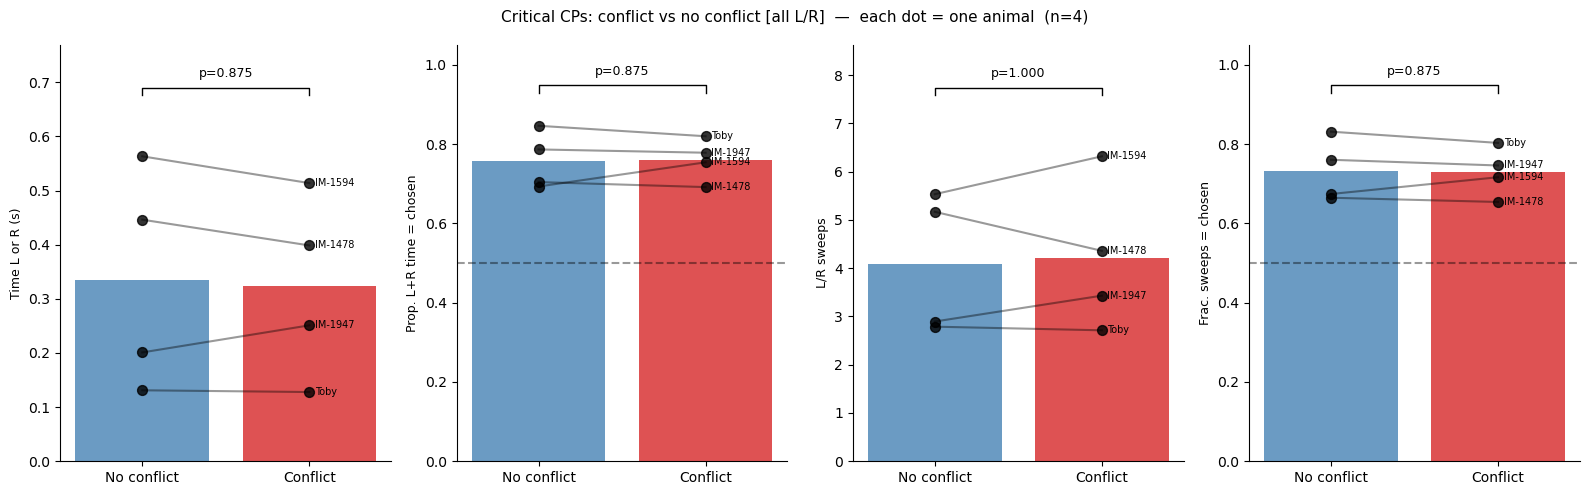

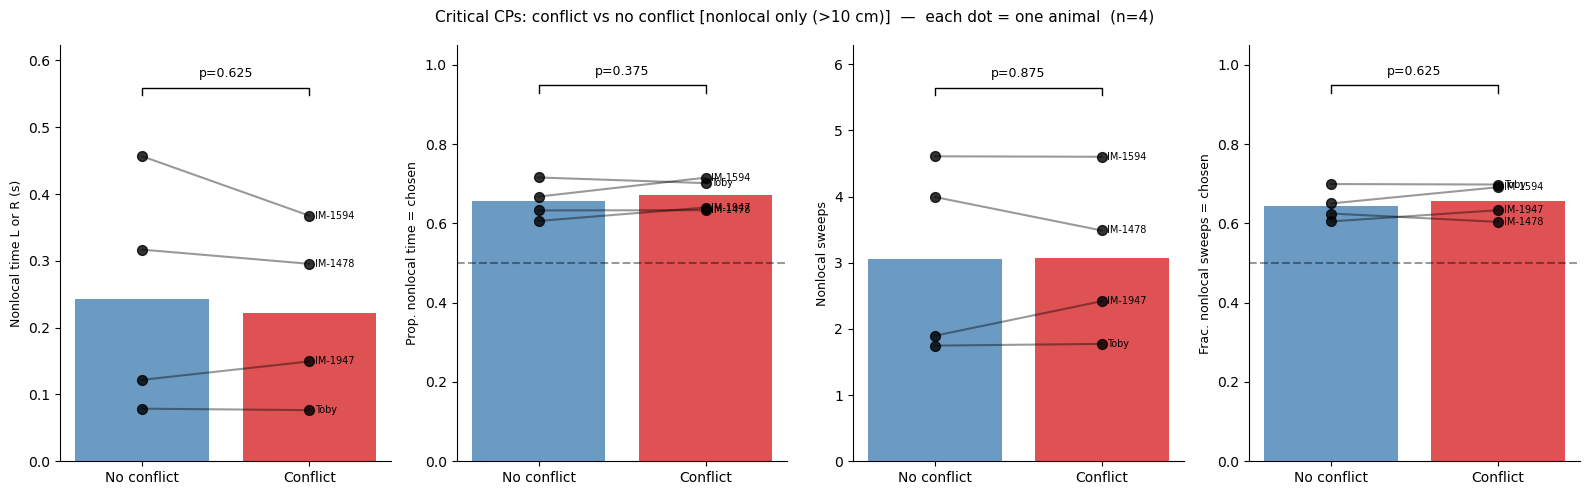

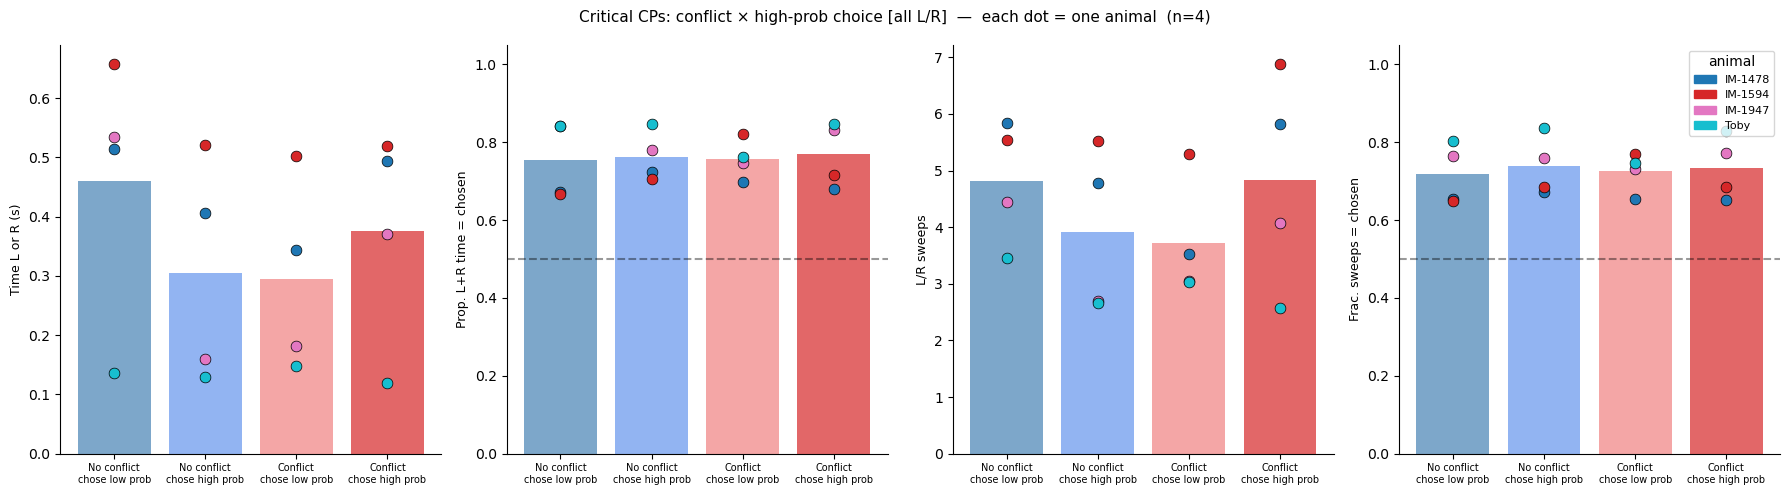

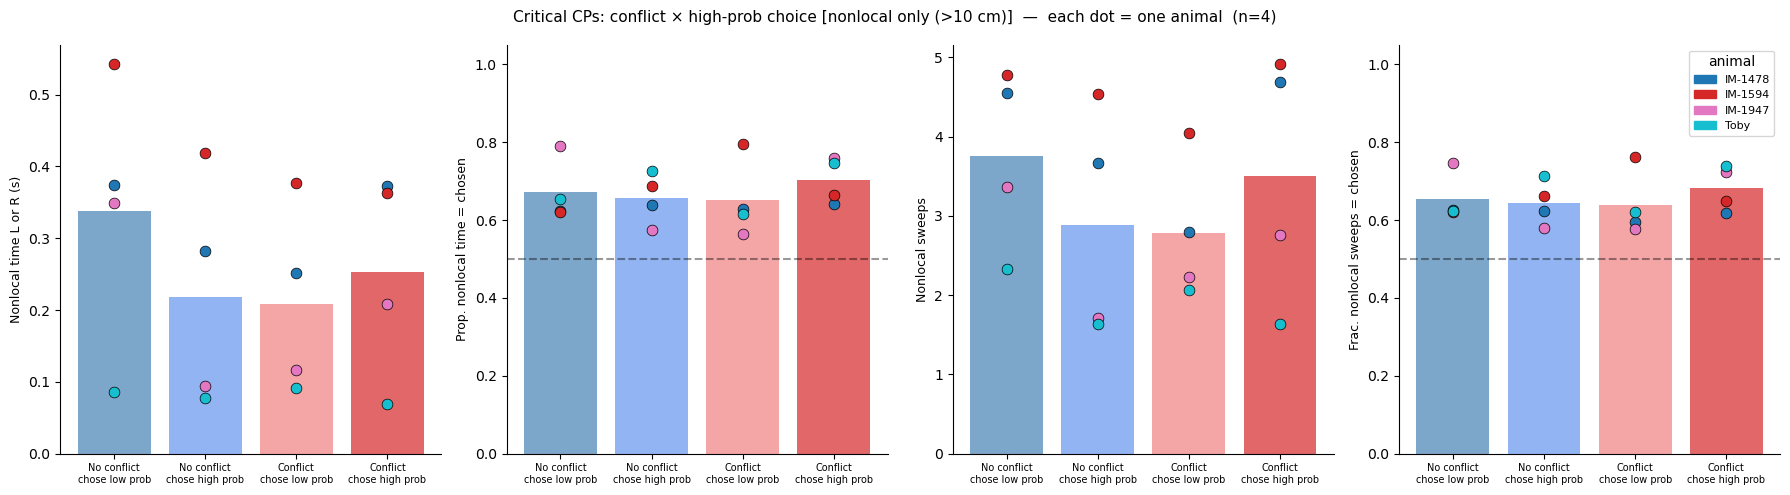

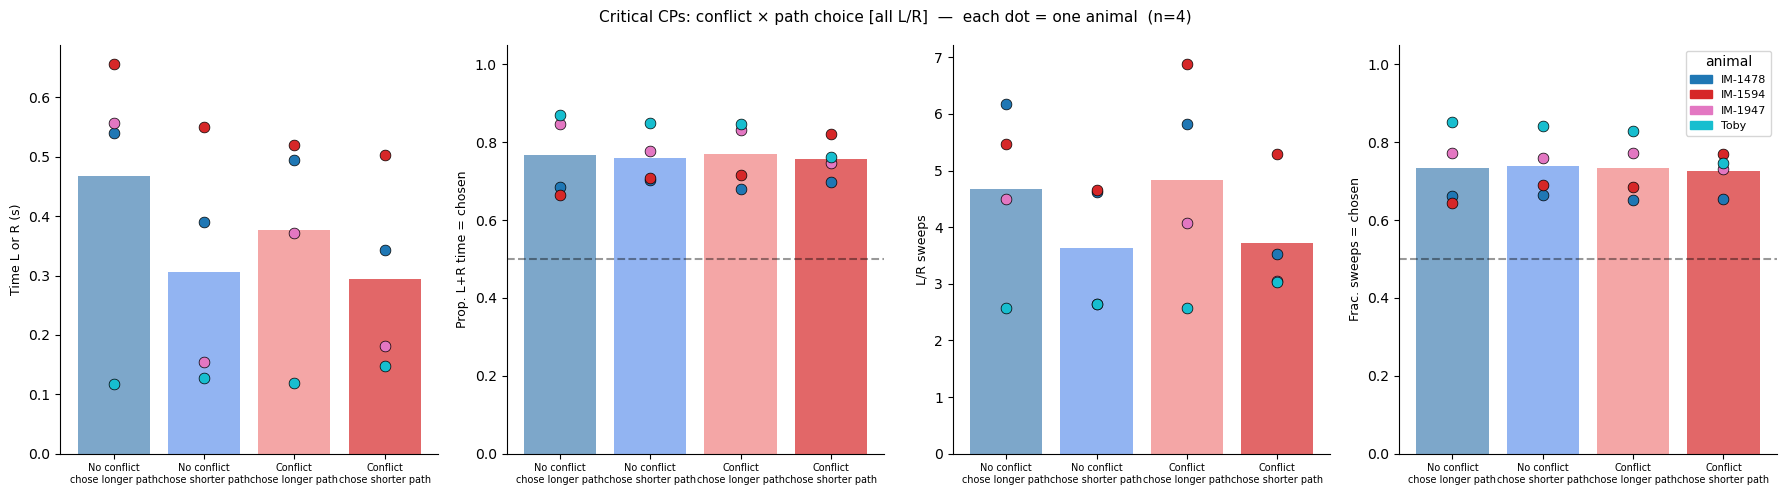

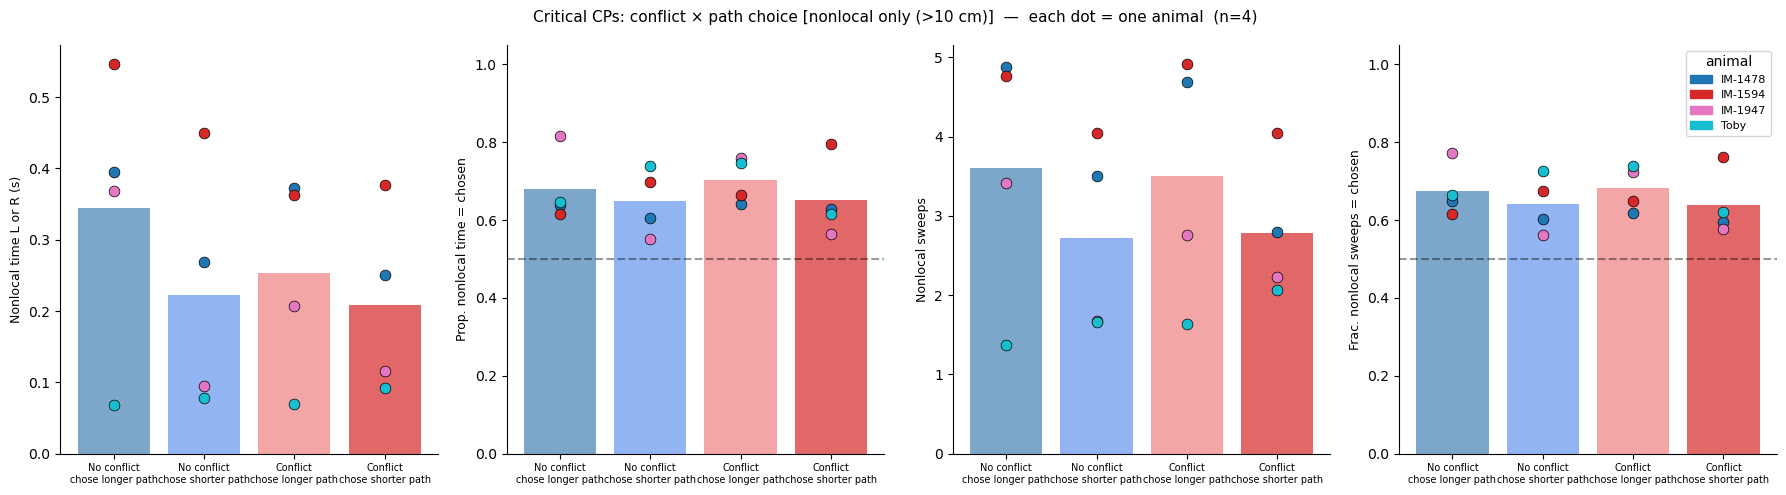

In [71]:
import re
import matplotlib.patches as mpatches
from scipy import stats

# Extract animal ID from nwb_file_name.
# Handles both formats:
#   IM-1478_20220719_.nwb  →  IM-1478   (underscore before 8-digit date)
#   Toby20250316_.nwb      →  Toby      (date runs directly after animal name)
def _extract_animal(nwb_name):
    m = re.match(r"^([A-Za-z0-9\-]+?)(?:_?\d{8})", nwb_name)
    return m.group(1) if m else nwb_name

# Helper: draw one paired bar+scatter for two conditions, one dot per animal.
# animal_vals is a DataFrame indexed by animal, with columns col_a and col_b.
def _plot_paired_animals(ax, animal_vals, col_a, col_b, color_a, color_b, metric, prop_metrics):
    # Mean bars
    ax.bar(0, animal_vals[col_a].mean(), color=color_a, alpha=0.8, zorder=1)
    ax.bar(1, animal_vals[col_b].mean(), color=color_b, alpha=0.8, zorder=1)
    # Dots and lines per animal, labeled
    for anim, row in animal_vals.iterrows():
        ax.plot([0, 1], [row[col_a], row[col_b]], color="k", alpha=0.4, linewidth=1.5, zorder=2)
        ax.scatter([0, 1], [row[col_a], row[col_b]], color="k", s=50, alpha=0.8, zorder=3)
        ax.annotate(str(anim), (1, row[col_b]), fontsize=7, va="center", ha="left",
                    xytext=(4, 0), textcoords="offset points")
    # Wilcoxon signed-rank test (falls back to showing n if too few animals to test)
    try:
        _, p = stats.wilcoxon(animal_vals[col_a], animal_vals[col_b])
        p_str = f"p={p:.3f}"
    except Exception:
        p_str = f"n={len(animal_vals)}"
    # Significance bracket
    if metric in prop_metrics:
        ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
        ax.set_ylim(0, 1.05)
        bracket_y = 0.93
    else:
        ax.set_ylim(top=ax.get_ylim()[1] * 1.3)
        bracket_y = ax.get_ylim()[1] * 0.88
    ax.plot([0, 0, 1, 1], [bracket_y, bracket_y * 1.02, bracket_y * 1.02, bracket_y], color="k", linewidth=1)
    ax.text(0.5, bracket_y * 1.04, p_str, ha="center", va="bottom", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Helper: draw a 2x2 category bar chart with one colored dot per animal.
# cat_df has columns: "animal", grouping cols (e.g. "conflict", "chose_high_prob"), and metric cols.
def _plot_2x2_animals(ax, cat_df, col_a, col_b, categories, metric, prop_metrics, animal_colors):
    for x, (val_a, val_b, cat_label, cat_color) in enumerate(categories):
        subset = cat_df[(cat_df[col_a] == val_a) & (cat_df[col_b] == val_b)]
        if len(subset) == 0:
            continue
        # Bar: cross-animal mean
        ax.bar(x, subset[metric].mean(), color=cat_color, alpha=0.7, zorder=1)
        # One dot per animal, colored by animal
        for _, row in subset.iterrows():
            ax.scatter(x, row[metric], color=animal_colors.get(row["animal"], "gray"),
                       s=60, zorder=3, edgecolors="k", linewidths=0.5)
    if metric in prop_metrics:
        ax.axhline(0.5, color="k", linestyle="--", alpha=0.4)
        ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels([c[2] for c in categories], fontsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Add animal column to the main dataframes
all_stats_df["animal"] = all_stats_df["nwb_file_name"].apply(_extract_animal)
stats_df["animal"]     = stats_df["nwb_file_name"].apply(_extract_animal)

n_animals   = all_stats_df["animal"].nunique()
animal_list = sorted(all_stats_df["animal"].unique())
print(f"Animals ({n_animals}): {animal_list}")

# Distinct color per animal (used in 2x2 breakdown plots)
animal_colors = dict(zip(animal_list, plt.cm.tab10(np.linspace(0, 0.9, max(len(animal_list), 2)))))

all_metric_cols = [
    "time_lr_s", "nonlocal_time_lr_s",
    "prop_chosen", "prop_nonlocal_chosen",
    "n_lr_sweeps", "n_nonlocal_sweeps",
    "frac_sweeps_chosen", "frac_nonlocal_sweeps_chosen",
]
prop_metrics = {"prop_chosen", "frac_sweeps_chosen", "prop_nonlocal_chosen", "frac_nonlocal_sweeps_chosen"}


# ── 1. Critical vs other junctions ─────────────────────────────────────────────
# Average all visits within each (animal, is_critical) combination, then pair up.
animal_means_crit = (
    all_stats_df
    .groupby(["animal", "is_critical"])
    [all_metric_cols].mean()
)

for metrics, label in [
    ([("time_lr_s",          "Time representing alternatives (s)"),
      ("prop_chosen",        "Fraction of time representing chosen arm"),
      ("n_lr_sweeps",        "Number of sweeps"),
      ("frac_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "all L/R"),
    ([("nonlocal_time_lr_s",          "Time representing alternatives (s)"),
      ("prop_nonlocal_chosen",         "Fraction of time representing chosen arm"),
      ("n_nonlocal_sweeps",           "Number of sweeps"),
      ("frac_nonlocal_sweeps_chosen", "Fraction of sweeps into chosen arm")],
     "nonlocal only (>10 cm)"),
]:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (metric, ylabel) in zip(axes, metrics):
        # pivot: rows = animals, columns = [False (other), True (critical)]
        paired = animal_means_crit[metric].unstack("is_critical").dropna()
        _plot_paired_animals(ax, paired, False, True, "steelblue", "tab:orange", metric, prop_metrics)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Other", "Critical CP"])
        ax.set_ylabel(ylabel, fontsize=9)
    fig.suptitle(
        f"Critical vs other [{label}]  —  each dot = one animal  (n={n_animals})",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()


# ── 2. First vs last trials ─────────────────────────────────────────────────────
# Requires block_half_means and HALF_SIZE from Cell 5.
if "block_half_means" in globals() and "HALF_SIZE" in globals():
    block_half_means["animal"] = block_half_means["nwb_file_name"].apply(_extract_animal)
    first_label = f"First {HALF_SIZE} trials"
    last_label  = f"Last {HALF_SIZE} trials"
    half_metrics_local = ["time_lr_s", "nonlocal_time_lr_s", "n_lr_sweeps", "n_nonlocal_sweeps"]
    half_metric_labels_local = [
        ("time_lr_s",          "Time L or R (s)"),
        ("n_lr_sweeps",        "L/R sweeps"),
        ("nonlocal_time_lr_s", "Remote time L or R (s)"),
        ("n_nonlocal_sweeps",  "Remote sweeps"),
    ]
    # Average blocks within each (animal, block_half) then pivot
    animal_half_means = (
        block_half_means.dropna(subset=["block_half"])
        .groupby(["animal", "block_half"])
        [half_metrics_local].mean()
    )
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, (metric, ylabel) in zip(axes, half_metric_labels_local):
        paired = animal_half_means[metric].unstack("block_half")
        if first_label in paired.columns and last_label in paired.columns:
            paired = paired[[first_label, last_label]].dropna()
            _plot_paired_animals(ax, paired, first_label, last_label, "lightgray", "dimgray", metric, prop_metrics)
        ax.set_xticks([0, 1])
        ax.set_xticklabels([first_label, last_label])
        ax.set_ylabel(ylabel, fontsize=9)
    fig.suptitle(
        f"Critical CP stats: first vs last {HALF_SIZE} trials  —  each dot = one animal  (n={n_animals})",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()
else:
    print("Skipping first/last plot — run Cell 5 first to populate block_half_means.")


# ── 3. Conflict vs no-conflict ──────────────────────────────────────────────────
# Requires stats_df to have conflict column (from Cell 12).
if "conflict" in stats_df.columns:
    df_valid_anim = stats_df.dropna(subset=["conflict"]).copy()
    df_valid_anim["animal"] = df_valid_anim["nwb_file_name"].apply(_extract_animal)

    # Average critical CP visits within each (animal, conflict) combination
    animal_means_conf = (
        df_valid_anim
        .groupby(["animal", "conflict"])
        [all_metric_cols].mean()
    )

    for metrics, label in [
        ([("time_lr_s",          "Time L or R (s)"),
          ("prop_chosen",        "Prop. L+R time = chosen"),
          ("n_lr_sweeps",        "L/R sweeps"),
          ("frac_sweeps_chosen", "Frac. sweeps = chosen")],
         "all L/R"),
        ([("nonlocal_time_lr_s",          "Nonlocal time L or R (s)"),
          ("prop_nonlocal_chosen",         "Prop. nonlocal time = chosen"),
          ("n_nonlocal_sweeps",           "Nonlocal sweeps"),
          ("frac_nonlocal_sweeps_chosen", "Frac. nonlocal sweeps = chosen")],
         "nonlocal only (>10 cm)"),
    ]:
        fig, axes = plt.subplots(1, 4, figsize=(16, 5))
        for ax, (metric, ylabel) in zip(axes, metrics):
            paired = animal_means_conf[metric].unstack("conflict").dropna()
            _plot_paired_animals(ax, paired, False, True, "steelblue", "tab:red", metric, prop_metrics)
            ax.set_xticks([0, 1])
            ax.set_xticklabels(["No conflict", "Conflict"])
            ax.set_ylabel(ylabel, fontsize=9)
        fig.suptitle(
            f"Critical CPs: conflict vs no conflict [{label}]  —  each dot = one animal  (n={n_animals})",
            fontsize=11
        )
        plt.tight_layout()
        plt.show()

    # ── 4. 2×2: conflict × chose_high_prob ─────────────────────────────────────
    # Requires prop_high_prob columns (from Cell 13).
    if "chose_high_prob" in df_valid_anim.columns:
        categories_hp = [
            (False, False, "No conflict\nchose low prob",  "steelblue"),
            (False, True,  "No conflict\nchose high prob", "cornflowerblue"),
            (True,  False, "Conflict\nchose low prob",     "lightcoral"),
            (True,  True,  "Conflict\nchose high prob",    "tab:red"),
        ]

        # Average all visits within each (animal, conflict, chose_high_prob) combination
        df_hp = df_valid_anim.dropna(subset=["chose_high_prob"])
        animal_2x2_hp = (
            df_hp
            .groupby(["animal", "conflict", "chose_high_prob"])
            [all_metric_cols].mean().reset_index()
        )

        for metrics, label in [
            ([("time_lr_s",          "Time L or R (s)"),
              ("prop_chosen",        "Prop. L+R time = chosen"),
              ("n_lr_sweeps",        "L/R sweeps"),
              ("frac_sweeps_chosen", "Frac. sweeps = chosen")],
             "all L/R"),
            ([("nonlocal_time_lr_s",          "Nonlocal time L or R (s)"),
              ("prop_nonlocal_chosen",         "Prop. nonlocal time = chosen"),
              ("n_nonlocal_sweeps",           "Nonlocal sweeps"),
              ("frac_nonlocal_sweeps_chosen", "Frac. nonlocal sweeps = chosen")],
             "nonlocal only (>10 cm)"),
        ]:
            fig, axes = plt.subplots(1, 4, figsize=(18, 5))
            for ax, (metric, ylabel) in zip(axes, metrics):
                _plot_2x2_animals(ax, animal_2x2_hp, "conflict", "chose_high_prob",
                                  categories_hp, metric, prop_metrics, animal_colors)
                ax.set_ylabel(ylabel, fontsize=9)
            # Animal legend on last axis
            handles = [mpatches.Patch(color=animal_colors[a], label=a) for a in animal_list]
            axes[-1].legend(handles=handles, fontsize=8, title="animal", loc="upper right")
            fig.suptitle(
                f"Critical CPs: conflict × high-prob choice [{label}]  —  each dot = one animal  (n={n_animals})",
                fontsize=11
            )
            plt.tight_layout()
            plt.show()

    # ── 5. 2×2: conflict × chose_short_path ────────────────────────────────────
    # Requires path_length_diff column (from Cell 12).
    if "path_length_diff" in df_valid_anim.columns:
        df_valid_anim["chose_short_path"] = df_valid_anim["path_length_diff"] < 0
        df_path = df_valid_anim[df_valid_anim["path_length_diff"] != 0]

        categories_path = [
            (False, False, "No conflict\nchose longer path",  "steelblue"),
            (False, True,  "No conflict\nchose shorter path", "cornflowerblue"),
            (True,  False, "Conflict\nchose longer path",     "lightcoral"),
            (True,  True,  "Conflict\nchose shorter path",    "tab:red"),
        ]

        animal_2x2_path = (
            df_path
            .groupby(["animal", "conflict", "chose_short_path"])
            [all_metric_cols].mean().reset_index()
        )

        for metrics, label in [
            ([("time_lr_s",          "Time L or R (s)"),
              ("prop_chosen",        "Prop. L+R time = chosen"),
              ("n_lr_sweeps",        "L/R sweeps"),
              ("frac_sweeps_chosen", "Frac. sweeps = chosen")],
             "all L/R"),
            ([("nonlocal_time_lr_s",          "Nonlocal time L or R (s)"),
              ("prop_nonlocal_chosen",         "Prop. nonlocal time = chosen"),
              ("n_nonlocal_sweeps",           "Nonlocal sweeps"),
              ("frac_nonlocal_sweeps_chosen", "Frac. nonlocal sweeps = chosen")],
             "nonlocal only (>10 cm)"),
        ]:
            fig, axes = plt.subplots(1, 4, figsize=(18, 5))
            for ax, (metric, ylabel) in zip(axes, metrics):
                _plot_2x2_animals(ax, animal_2x2_path, "conflict", "chose_short_path",
                                  categories_path, metric, prop_metrics, animal_colors)
                ax.set_ylabel(ylabel, fontsize=9)
            handles = [mpatches.Patch(color=animal_colors[a], label=a) for a in animal_list]
            axes[-1].legend(handles=handles, fontsize=8, title="animal", loc="upper right")
            fig.suptitle(
                f"Critical CPs: conflict × path choice [{label}]  —  each dot = one animal  (n={n_animals})",
                fontsize=11
            )
            plt.tight_layout()
            plt.show()

else:
    print("Skipping conflict plots — run Cell 12 first to add conflict column to stats_df.")